<div style="text-align: center; margin-top: 120px;">

# TRABAJO INDIVIDUAL REGRESIÓN  
# DATA MINING  

<br><br>

**Universidad Carlos III de Madrid**  

<br><br>

**Autor**

 
Carlos Balsa Gómez  

<br><br>

*Jupyter Notebook*  

</div>

# 1. Introducción al trabajo y conjunto de datos

Esta práctica es el entregable como trabajo grupal individual para la asignatura de *Métodos estadísticos en minería de datos*

En este trabajo se utilizará la base de datos de `enhanced_student_habits_performance_dataset.csv` , el objetivo de esta práctica es aplicar una serie de conocimientos acerca de la visualización de datos, la reducción de la dimensión y de modelos de árbol de decisión además de redes neuronales. A grandes rasgos lo primero que se ha hecho es preparar los datos y conocer más a fondo el dataset con el que se va a trabajar. Posteriormente se verá más detalladamente como llegamos a un punto donde tenemos dos fases, la FASE A donde realizaremos un PCA y crearemos clusters y la FASE B donde utilizando esos clusters probaremos distintos modelos de regresión y comprobaremos si mejora la implementación de estos si se prepara un modelo por cada cluster o uno para el conjunto global.

En cuanto a nuestro conjunto de datos y la tarea a resolver se trata de unos datos con registros de 80000 alumnos, de los cuales se tienen diferentes métricas de ellos que buscan ser útiles a la hora de predecir nuestra variable objetivo que es el resultado del examen. Esta base de datos me pareció interesante ya que se pueden ver que factores son los más decisivos para que un estudiante saque altas o bajas notas, ademas de entender el perfil de un buen estudiante y el de uno malo, yo al ser estudiante quiero ver si me puedo ver reflejado en los futuros resultados que obtenga con los diferentes modelos.

In [1]:
import warnings
warnings.filterwarnings("ignore")  # Ignora warnings de Python

import tensorflow as tf
tf.get_logger().setLevel('ERROR')  # Solo muestra errores de TF, ignora warnings


In [2]:
# Manipulación de datos
import pandas as pd
import numpy as np
from scipy import stats

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import networkx as nx

# Preprocesamiento y reducción de dimensionalidad
from sklearn.preprocessing import RobustScaler, normalize
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score

# Reglas de asociación
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Modelos y evaluación
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# Redes neuronales
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 3D plot
from mpl_toolkits.mplot3d import Axes3D


Lo primero que hacemos es cargar nuestro csv, guardarlo en un data frame y ver las primeras cinco filas de nuestros datos.

In [3]:
# 1. Define el nombre del archivo
nombre_archivo = 'enhanced_student_habits_performance_dataset.csv'

# 2. Carga el archivo directamente en un DataFrame
df = pd.read_csv(nombre_archivo)

# 3. Opcional: Imprime las primeras filas para confirmar que funcionó
print(df.head())

   student_id  age  gender             major  study_hours_per_day  \
0      100000   26    Male  Computer Science             7.645367   
1      100001   28    Male              Arts             5.700000   
2      100002   17    Male              Arts             2.400000   
3      100003   27   Other        Psychology             3.400000   
4      100004   25  Female          Business             4.700000   

   social_media_hours  netflix_hours part_time_job  attendance_percentage  \
0                 3.0            0.1           Yes                   70.3   
1                 0.5            0.4            No                   88.4   
2                 4.2            0.7            No                   82.1   
3                 4.6            2.3           Yes                   79.3   
4                 0.8            2.7           Yes                   62.9   

   sleep_hours  ... screen_time  study_environment access_to_tutoring  \
0          6.2  ...        10.9  Co-Learning Grou

Vemos como vamos a tener unas cuantas variables que van a ser continuas pero también tendremos otras que serán categóricas aunque eso lo vemos más claramente en el siguiente codigo utilizando la función `info`

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     80000 non-null  int64  
 1   age                            80000 non-null  int64  
 2   gender                         80000 non-null  object 
 3   major                          80000 non-null  object 
 4   study_hours_per_day            80000 non-null  float64
 5   social_media_hours             80000 non-null  float64
 6   netflix_hours                  80000 non-null  float64
 7   part_time_job                  80000 non-null  object 
 8   attendance_percentage          80000 non-null  float64
 9   sleep_hours                    80000 non-null  float64
 10  diet_quality                   80000 non-null  object 
 11  exercise_frequency             80000 non-null  int64  
 12  parental_education_level       80000 non-null 

Aqui podemos ya ver varías cosas que nos preocupaban, una que es positiva y es que nuestro dataset como se ve no tiene ningun valor nulo por lo que no nos tenemos que preocupar por imputar por el metodo de imputar y por la fuga de información que puede conllevar si se hace mal. Lo principal que vemos es que tenemos tres tipos de variables, `object`, `float64` y `int64`. Que mas adelante veremos en que proproción y si nos da problemas

In [5]:
# 1. Simulación de carga del DataFrame (Asumiendo que 'df' ya está cargado)
# df = pd.read_csv('enhanced_student_habits_performance_dataset.csv')
# Aseguramos que se muestren todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# ----------------------------------------------------
# 2. Conteo de Tipos de Datos por Categoría
# ----------------------------------------------------

print("--- Conteo de Variables por Tipo de Dato (Dtype) ---")
# df.dtypes.value_counts() resume cuántas columnas hay de cada tipo
print(df.dtypes.value_counts())

print("\n" + "="*50 + "\n")



--- Conteo de Variables por Tipo de Dato (Dtype) ---
object     12
float64    10
int64       9
Name: count, dtype: int64




Vemos que el dataset tiene 12 variables categóricas, 10 numéricas continuas y 9 numéricas enteras. Las categóricas suelen requerir transformación (como One-Hot Encoding) para que los modelos puedan utilizarlas, mientras que las numéricas permiten un tratamiento más directo mediante escalado. Este recuento sirve para entender cómo debe prepararse cada tipo de variable antes de entrenar los modelos.

A continuación queremos ver solo las categorías de tipo `object` y conocer sus nombres.

In [6]:
# 1. Simulación de carga del DataFrame (Asumiendo que 'df' ya está cargado)
# df = pd.read_csv('enhanced_student_habits_performance_dataset.csv')

# 2. Seleccionar solo las columnas de tipo 'object'
columnas_object = df.select_dtypes(include=['object']).columns

# 3. Convertir a una lista de Python e imprimir para evitar el truncamiento
print("--- Nombres de las 12 Variables Categóricas (Tipo 'object') ---")
print(columnas_object.tolist())

--- Nombres de las 12 Variables Categóricas (Tipo 'object') ---
['gender', 'major', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation', 'dropout_risk', 'study_environment', 'access_to_tutoring', 'family_income_range', 'learning_style']


Una vez identificadas las variables categóricas, es importante revisar cuántas categorías tiene cada una. Si alguna presenta demasiadas categorías, el One-Hot Encoding generaría muchas columnas nuevas, aumentando la dimensionalidad y el coste computacional, además del riesgo de sobreajuste. Por eso conviene comprobar este aspecto

In [7]:
# 1. Simulación de carga del DataFrame (Asumiendo que 'df' ya está cargado)
# df = pd.read_csv('enhanced_student_habits_performance_dataset.csv')

# 2. Definición de las columnas categóricas
columnas_object = ['gender', 'major', 'part_time_job', 'diet_quality', 'parental_education_level', 
                   'internet_quality', 'extracurricular_participation', 'dropout_risk', 
                   'study_environment', 'access_to_tutoring', 'family_income_range', 'learning_style']

print("--- Análisis de Cardinalidad y Categorías ---")

for columna in columnas_object:
    # 3. Obtener el número de valores únicos
    num_unicos = df[columna].nunique()
    
    print(f"\n=============================================")
    print(f"COLUMNA: {columna}")
    print(f"Cardinalidad (Categorías Únicas): {num_unicos}")
    
    # 4. Mostrar las categorías y su conteo. Mostramos todas si son pocas (<= 10) o las 10 principales si son muchas.
    if num_unicos <= 10:
        print("Conteo de todas las categorías:")
        # Usamos .to_string() para asegurar que la salida no se trunque
        print(df[columna].value_counts().to_string())
    else:
        print(f"Top 10 categorías (de un total de {num_unicos}):")
        print(df[columna].value_counts().head(10).to_string())

--- Análisis de Cardinalidad y Categorías ---

COLUMNA: gender
Cardinalidad (Categorías Únicas): 3
Conteo de todas las categorías:
gender
Female    26705
Male      26698
Other     26597

COLUMNA: major
Cardinalidad (Categorías Únicas): 6
Conteo de todas las categorías:
major
Arts                13505
Psychology          13437
Computer Science    13352
Business            13276
Engineering         13229
Biology             13201

COLUMNA: part_time_job
Cardinalidad (Categorías Únicas): 2
Conteo de todas las categorías:
part_time_job
No     40195
Yes    39805

COLUMNA: diet_quality
Cardinalidad (Categorías Únicas): 3
Conteo de todas las categorías:
diet_quality
Good    39935
Fair    26713
Poor    13352

COLUMNA: parental_education_level
Cardinalidad (Categorías Únicas): 5
Conteo de todas las categorías:
parental_education_level
Some College    16115
High School     16106
Bachelor        15986
Master          15908
PhD             15885

COLUMNA: internet_quality
Cardinalidad (Categorías 

Vemos que afortunadamente ninguna variable tiene muchas clases dentro de ella, la que mas la de `major` que tiene 6 y tratandose de 80000 filas es muy poco, por lo que decidimos que es muy vuable realizar el One-Hot Encoding para nuestro dataset con las variables categóricas,

En este bloque siguiente se aplica One-Hot Encoding a todas las variables categóricas del DataFrame. Esto convierte cada categoría en una columna binaria (0 o 1), lo que permite que los modelos matemáticos y de machine learning trabajen con estas variables.

Se usa drop_first=True para evitar multicolinealidad, es decir, para que no haya redundancia entre las columnas generadas. Luego se verifica que todas las columnas categóricas hayan sido transformadas y se imprime la nueva forma del DataFrame para confirmar el cambio. Esto prepara los datos para poder entrenar modelos sin problemas de variables tipo object.

In [8]:
# Definición de las 12 columnas categóricas (tipo object)
columnas_object = ['gender', 'major', 'part_time_job', 'diet_quality', 'parental_education_level', 
                   'internet_quality', 'extracurricular_participation', 'dropout_risk', 
                   'study_environment', 'access_to_tutoring', 'family_income_range', 'learning_style']

print("--- Aplicando One-Hot Encoding y reasignando a df ---")

# Aplicar One-Hot Encoding y guardar el resultado en el DataFrame 'df'
# drop_first=True elimina la primera categoría de cada variable para evitar multicolinealidad.
df = pd.get_dummies(df, 
                    columns=columnas_object, 
                    drop_first=True)

# --------------------------------------------------------------------------------------
# Verificación del resultado
# --------------------------------------------------------------------------------------

print(f"Dimensiones del DataFrame final: {df.shape}")
print(f"Número de columnas original: {df.shape[1]}") # Este valor será el número total de columnas tras la codificación

print("\nPrimeras 5 filas del DataFrame 'df' (ahora codificado):")
print(df.head())

# Confirmar que no quedan variables 'object'
print("\nVerificación: Columnas de tipo 'object' restantes:")
print(df.select_dtypes(include=['object']).columns.tolist())

--- Aplicando One-Hot Encoding y reasignando a df ---
Dimensiones del DataFrame final: (80000, 47)


Número de columnas original: 47

Primeras 5 filas del DataFrame 'df' (ahora codificado):
   student_id  age  study_hours_per_day  social_media_hours  netflix_hours  attendance_percentage  sleep_hours  exercise_frequency  mental_health_rating  previous_gpa  semester  stress_level  social_activity  screen_time  parental_support_level  motivation_level  exam_anxiety_score  time_management_score  exam_score  gender_Male  gender_Other  major_Biology  major_Business  major_Computer Science  major_Engineering  major_Psychology  part_time_job_Yes  diet_quality_Good  diet_quality_Poor  parental_education_level_High School  parental_education_level_Master  parental_education_level_PhD  parental_education_level_Some College  internet_quality_Low  internet_quality_Medium  extracurricular_participation_Yes  dropout_risk_Yes  study_environment_Co-Learning Group  study_environment_Dorm  study_environment_Library  study_environment_Quiet Room  access_to_tutoring_Yes  family_income_range_Low  family_i

Vemos que tenemos ahora más variables como ya sabiamos y que no quedan del tipo que queríamos quitar.

En el siguiente codigo simplemente eliminamos la variable del id del estudiante ya que no nos va a aportar ninguna información y solo puede confuindir a los modelos.

In [9]:
# Eliminamos student_id del DataFrame para evitar problemas futuros
if 'student_id' in df.columns:
    df = df.drop('student_id', axis=1)
    print("La columna 'student_id' ha sido eliminada del DataFrame df.")
    print(f"Nuevo número de columnas de df: {df.shape[1]}")
else:
    print("La columna 'student_id' no se encontró o ya fue eliminada.")

df.info()

La columna 'student_id' ha sido eliminada del DataFrame df.
Nuevo número de columnas de df: 46
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    80000 non-null  int64  
 1   study_hours_per_day                    80000 non-null  float64
 2   social_media_hours                     80000 non-null  float64
 3   netflix_hours                          80000 non-null  float64
 4   attendance_percentage                  80000 non-null  float64
 5   sleep_hours                            80000 non-null  float64
 6   exercise_frequency                     80000 non-null  int64  
 7   mental_health_rating                   80000 non-null  float64
 8   previous_gpa                           80000 non-null  float64
 9   semester                               8000

En este bloque se identifican todas las variables numéricas continuas del DataFrame (tipo int64 o float64) y se calculan estadísticas descriptivas básicas como media, desviación estándar, mínimo y máximo.

Esto sirve para entender la distribución y escala de los datos, detectar posibles valores atípicos o rangos muy distintos entre variables ( aunque lo veremos en profundidad más adelante ) y preparar el terreno para escalado y modelado posterior.

In [10]:
# 1. Identificar TODAS las variables continuas (int64 y float64)
# NO EXCLUIMOS NINGUNA variable objetivo.
columnas_continuas_y_objetivo = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("--- Estadísticas Descriptivas de TODAS las Variables Continuas (Escala) ---")
# Esto muestra la media, desviación estándar, min y max de todas las columnas.
print(df[columnas_continuas_y_objetivo].describe().T)

--- Estadísticas Descriptivas de TODAS las Variables Continuas (Escala) ---


                          count       mean        std    min    25%        50%    75%    max
age                     80000.0  22.004288   3.745570  16.00  19.00  22.000000   25.0   28.0
study_hours_per_day     80000.0   4.174388   2.004135   0.00   2.80   4.125624    5.5   12.0
social_media_hours      80000.0   2.501366   1.445441   0.00   1.20   2.500000    3.8    5.0
netflix_hours           80000.0   1.997754   1.155992   0.00   1.00   2.000000    3.0    4.0
attendance_percentage   80000.0  69.967884  17.333015  40.00  55.00  69.900000   84.9  100.0
sleep_hours             80000.0   7.017417   1.467377   4.00   6.00   7.000000    8.0   12.0
exercise_frequency      80000.0   3.516587   2.291575   0.00   2.00   4.000000    6.0    7.0
mental_health_rating    80000.0   6.804107   1.921579   1.00   5.50   6.900000    8.2   10.0
previous_gpa            80000.0   3.602448   0.462876   1.64   3.27   3.790000    4.0    4.0
semester                80000.0   4.497338   2.295312   1.00   2.00   

En estas estadísticas se puede ver, por ejemplo, que la edad promedio de los estudiantes es de unos 22 años, con un rango bastante normal de 16 a 28 años.

El `exam_score` tiene una media bastante alta, alrededor de 89, y muchos estudiantes alcanzan el máximo (100), lo que indica que la mayoría obtiene buenas calificaciones.

Además, algunas variables como `screen_time` muestran valores extremos hasta 21 horas, lo que podría indicar estudiantes con hábitos de uso de dispositivos muy intensos,que más adelante veremos ese fenonemo del screen time, mientras que variables como `study_hours_per_day` tienen una media de 4 horas, con algunos que no estudian nada y otros hasta 12 horas.

En general, estas estadísticas ayudan a entender la distribución y dispersión de los datos antes de escalar o modelar.

Este bloque sirve para detectar valores atípicos (outliers) en las variables continuas usando el Z-score, que mide cuántas desviaciones estándar se aleja un valor de la media.

Se fija un umbral de |Z| > 3, es decir, cualquier valor que esté a más de 3 desviaciones estándar de la media se considera atípico.

El resultado te dice cuántos outliers hay por variable y su porcentaje relativo al total de filas. Esto ayuda a identificar variables que podrían necesitar tratamiento especial, como recorte, transformación o revisión, antes de escalar o modelar.

In [11]:
# Se asume que 'df' es tu DataFrame con One-Hot Encoding y 'student_id' eliminado.

# Identificar las 18 variables continuas para el análisis
columnas_continuas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("--- Análisis de Outliers por Z-Score (Umbral: |Z| > 3) ---")
outliers_conteo = {}
total_filas = len(df)

for columna in columnas_continuas:
    # Calcular el Z-score para cada valor
    z_scores = np.abs(stats.zscore(df[columna]))
    
    # Contar los valores donde el Z-score es mayor a 3
    outliers_count = np.sum(z_scores > 3)
    
    if outliers_count > 0:
        outliers_conteo[columna] = outliers_count
        
    
if outliers_conteo:
    # Convertir el resultado a un DataFrame para una mejor visualización
    df_outliers = pd.DataFrame(list(outliers_conteo.items()), columns=['Variable', 'Outliers'])
    df_outliers['Porcentaje'] = (df_outliers['Outliers'] / total_filas) 
    print(df_outliers.to_string(index=False))
else:
    print("No se detectaron outliers con un Z-score > 3 en las variables continuas.")

--- Análisis de Outliers por Z-Score (Umbral: |Z| > 3) ---


            Variable  Outliers  Porcentaje
 study_hours_per_day       147    0.001837
         sleep_hours       118    0.001475
mental_health_rating       184    0.002300
        previous_gpa       267    0.003338
         screen_time       103    0.001288
          exam_score       467    0.005837


Este resultado nos dice que hay pocos outliers en proporción al total de datos (80 000 filas).

Por ejemplo:

`exam_score` tiene 467 outliers, que representan ~0,58 % de los estudiantes.

`previous_gpa` tiene 267 outliers (~0,33 %).

Otras variables como `study_hours_per_day`, `sleep_hours`, `mental_health_rating` y `screen_time` también tienen algunos valores atípicos, pero todos por debajo del 0,25 %.

En general, la cantidad de outliers es pequeña, por lo que probablemente no afecten demasiado los modelos, pero es útil conocerlos por si quieres aplicar técnicas como recorte, winsorizing o transformaciones antes del escalado.

También es interesante usar los boxplots para ver esta distribución de outliers y ver que variables tienen y cuales no y su estructura.


--- Visualización de Outliers con Boxplots ---


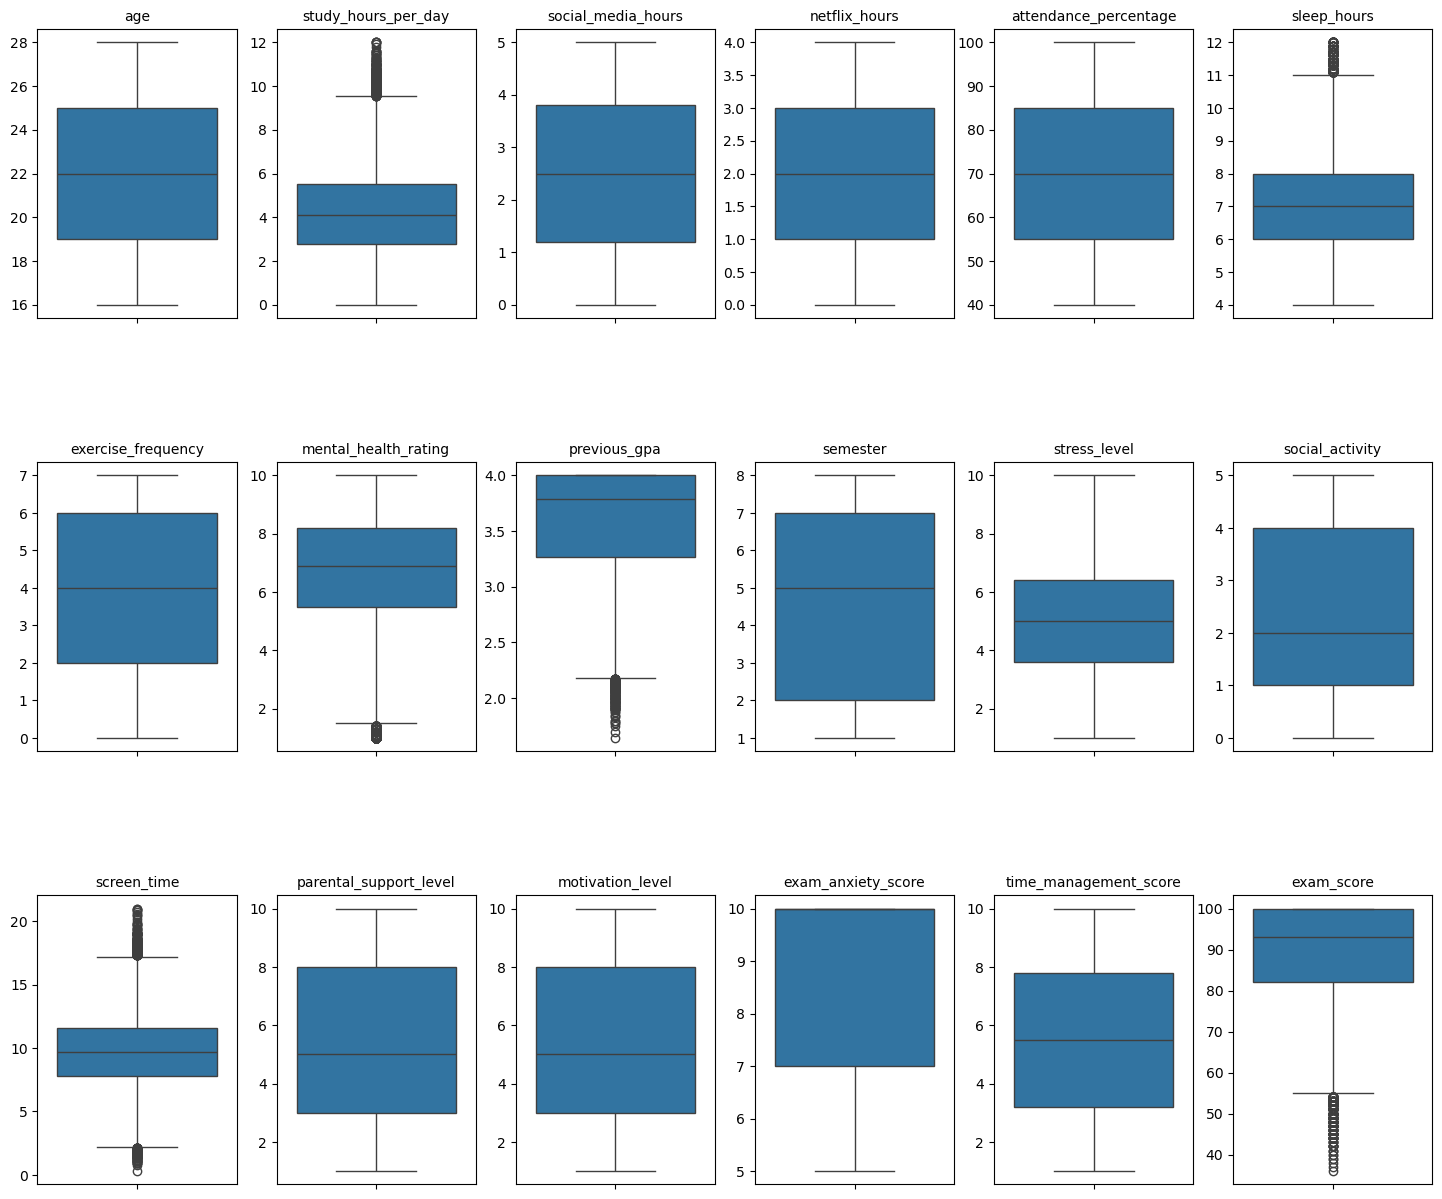

In [12]:
# Se asume que 'df' y 'columnas_continuas' ya están definidas.

print("\n--- Visualización de Outliers con Boxplots ---")

# Configurar el grid para 18 variables
n_cols = 6
n_rows = len(columnas_continuas) // n_cols + (len(columnas_continuas) % n_cols > 0)

plt.figure(figsize=(18, 5 * n_rows))
plt.subplots_adjust(hspace=0.5)

for i, columna in enumerate(columnas_continuas):
    plt.subplot(n_rows, n_cols, i + 1)
    # Crear el boxplot
    sns.boxplot(y=df[columna])
    plt.title(columna, fontsize=10)
    plt.ylabel('')
    plt.xlabel('')

# Mostrar todos los gráficos
plt.show()

Gracias a estos boxplots vemos los outliers que veiamos antes de una manera más gráfica.

A continuación me ha parecido interesante conocer cuantos estudiantes tenian un dato de más de 20 horas al dia mirando la pantalla porque me parecia un dato casi irreal y poco mantenible en el tiempo, puede haber sido una exageración o habitos completamente insanos de algunos estudiantes.

In [13]:
# 1. Definir el umbral de las 20 horas
umbral_horas = 20

# 2. Aplicar el filtro booleano a la columna 'screen_time'
estudiantes_extremos = df[df['screen_time'] > umbral_horas]

# 3. Contar el número de filas que cumplen la condición
conteo_estudiantes = estudiantes_extremos.shape[0]

print(f"--- Análisis de Screen Time Extremo ---")
print(f"El número de estudiantes con más de {umbral_horas} horas de screen time es: {conteo_estudiantes}")

--- Análisis de Screen Time Extremo ---
El número de estudiantes con más de 20 horas de screen time es: 9


Vemos que son solamente 9 alumnos de 80000 alumnos lo que representa un porcentaje infimo, pero igualmente me pareció curioso saber cuántos alumnos podían tener esos datos, igualmente la media ya es bastante alta aunque teniendo que actualmente mucha gente trabaja y estudia con pantallas quizás no sea tan raro.

Este bloque sirve para explorar cómo se relacionan entre sí las variables continuas del dataset:

Primero selecciona todas las variables continuas, incluyendo `exam_score` para ver cómo se correlaciona con las demás.

Calcula la matriz de correlación y la visualiza con un heatmap, lo que permite identificar rápidamente relaciones fuertes o débiles.

Finalmente extrae los pares de variables con correlación alta (|r| > 0.7) para detectar posibles problemas de multicolinealidad, que pueden afectar modelos sensibles a redundancias en los predictores.

En conjunto, este bloque ayuda a entender dependencias internas entre variables y a tomar decisiones sobre transformación o selección de características.

--- 1. Matriz de Correlación: Solo Variables Continuas ---


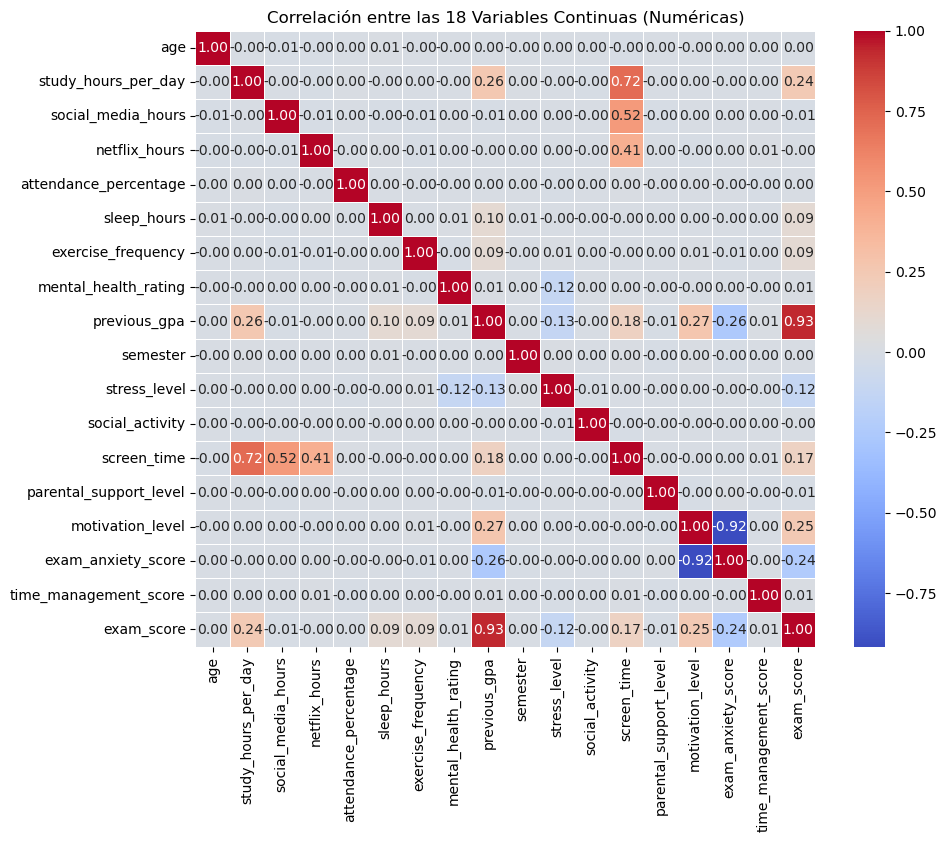


Top 5 correlaciones más fuertes (Multicolinealidad):
exam_score           previous_gpa           0.932940
previous_gpa         exam_score             0.932940
study_hours_per_day  screen_time            0.717972
screen_time          study_hours_per_day    0.717972
motivation_level     exam_anxiety_score    -0.916804
exam_anxiety_score   motivation_level      -0.916804


In [14]:
# Se asume que 'df' es tu DataFrame escalado y codificado.
# 1. Identificar las 18 variables continuas (int64 y float64)
# (Incluyendo 'exam_score' para ver su relación con las demás continuas)
columnas_continuas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("--- 1. Matriz de Correlación: Solo Variables Continuas ---")

# 2. Calcular la matriz de correlación solo para esas 18 columnas
matriz_continuas = df[columnas_continuas].corr()

# 3. Visualización con un Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_continuas, 
            annot=True,        # Mantener las anotaciones porque la matriz es pequeña
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)
plt.title('Correlación entre las 18 Variables Continuas (Numéricas)')
plt.show() 

# 4. Revisión de Correlaciones más fuertes (Opcional, para complementar)
print("\nTop 5 correlaciones más fuertes (Multicolinealidad):")
# Encontrar pares de correlación alta (ej., |r| > 0.7)
pares_fuertes = matriz_continuas.unstack().sort_values(ascending=False)
pares_fuertes = pares_fuertes[pares_fuertes != 1]
print(pares_fuertes[abs(pares_fuertes) > 0.7].head(10).to_string())

EN las conclusiones del Heatmap vemos esto: 
La variable `exam_score` presenta una fuerte correlación positiva con `previous_gpa` (0.93), lo que indica que los estudiantes con un mejor desempeño previo tienden a obtener mejores calificaciones en los exámenes actuales.

`study_hours_per_day` y `screen_time` muestran una correlación positiva moderada (0.72), sugiriendo que quienes dedican más tiempo al estudio también tienden a pasar más tiempo frente a pantallas, aunque esto podría reflejar un comportamiento combinado de ocio y estudio.

`motivation_level` y `exam_anxiety_score` presentan una fuerte correlación negativa (-0.92), señalando que un mayor nivel de motivación está asociado a menores niveles de ansiedad ante los exámenes.

Estas relaciones ayudan a entender mejor la dinámica entre las variables y sirven para evaluar posibles problemas de multicolinealidad, aunque los modelos basados en árboles no se ven afectados de manera significativa por ello.

Decidí eliminar la variable previous_gpa del análisis y de los modelos porque considero que puede introducir un sesgo artificial en la predicción de exam_score. Esta variable refleja directamente el desempeño académico previo del estudiante y, al estar fuertemente correlacionada con la nota actual (0.93), incluirla podría considerarse “hacer trampa”, ya que facilita la predicción sin que el modelo realmente aprenda de los hábitos y características que quiero estudiar. Al excluirla, me aseguro de que los modelos se centren en factores de comportamiento, estilo de vida y otras variables que realmente podrían influir en el rendimiento académico.

In [15]:
if 'previous_gpa' in df.columns:
    df = df.drop('previous_gpa', axis=1)
    print("La columna 'previous_gpa' ha sido eliminada del DataFrame df.")
    print(f"Nuevo número de columnas de df: {df.shape[1]}")
else:
    print("La columna 'previous_gpa' no se encontró o ya fue eliminada.")

La columna 'previous_gpa' ha sido eliminada del DataFrame df.
Nuevo número de columnas de df: 45


En este bloque analizo cómo las variables categóricas, codificadas mediante One-Hot Encoding, se relacionan con la variable objetivo exam_score. Aunque todavía no he escalado los datos, esto no afecta al análisis porque las variables One-Hot son binarias (0 o 1) y, por lo tanto, sus correlaciones se pueden calcular directamente.

In [16]:
# Nombres de las 11 variables categóricas originales que generan las columnas One-Hot.
# (12 originales - 1 'dropout_risk' si ya la eliminaste, o 11 si solo usaste 11)
# Asumiremos la lista original de 12 nombres para la identificación de prefijos.
prefijos_one_hot = [
    'gender', 'major', 'part_time_job', 'diet_quality', 'parental_education_level', 
    'internet_quality', 'extracurricular_participation', 'dropout_risk', 
    'study_environment', 'access_to_tutoring', 'family_income_range', 'learning_style'
]

# 1. Identificar las columnas One-Hot usando los prefijos
# Buscamos columnas que comiencen con uno de los prefijos y un guion bajo (después del drop_first=True)
columnas_one_hot_final = [
    col for col in df.columns 
    if any(col.startswith(f'{prefijo}_') for prefijo in prefijos_one_hot)
]

print(f"--- Correlación de {len(columnas_one_hot_final)} Variables Categóricas con 'exam_score' ---")

# 2. Calcular las correlaciones
correlaciones_oh_con_objetivo = df[columnas_one_hot_final].corrwith(df['exam_score']).sort_values(ascending=False)

# 3. Mostrar los resultados
print("Top 10 Correlaciones Positivas (Categorías que ayudan al rendimiento):")
print(correlaciones_oh_con_objetivo.head(10).to_string())

print("\nTop 10 Correlaciones Negativas (Categorías que afectan el rendimiento):")
print(correlaciones_oh_con_objetivo.tail(10).sort_values(ascending=True).to_string())

--- Correlación de 28 Variables Categóricas con 'exam_score' ---
Top 10 Correlaciones Positivas (Categorías que ayudan al rendimiento):
access_to_tutoring_Yes                 0.120398
study_environment_Quiet Room           0.091314
study_environment_Co-Learning Group    0.044522
major_Computer Science                 0.043651
study_environment_Library              0.039943
extracurricular_participation_Yes      0.003738
learning_style_Kinesthetic             0.002906
internet_quality_Low                   0.002700
family_income_range_Low                0.002559
parental_education_level_PhD           0.002086

Top 10 Correlaciones Negativas (Categorías que afectan el rendimiento):
study_environment_Dorm                  -0.152248
dropout_risk_Yes                        -0.088312
major_Psychology                        -0.011603
major_Biology                           -0.011167
diet_quality_Good                       -0.008448
major_Business                          -0.006999
family_inco

En este análisis veo que algunas categorías tienen una correlación positiva clara con `exam_score`, por ejemplo `access_to_tutoring_Yes` (0.12) y `study_environment_Quiet Room` (0.09), lo que indica que los estudiantes que reciben tutorías o estudian en un ambiente tranquilo tienden a rendir mejor.

Por otro lado, algunas categorías muestran correlación negativa, como `study_environment_Dorm` (-0.15) o `dropout_risk_Yes` (-0.088), lo que sugiere que estudiar en el dormitorio o tener riesgo de abandono está asociado con menores calificaciones

# FASE 1

La Fase 1 de manera general consiste en preparar los datos para poder identificar patrones en los hábitos de los estudiantes. Primero, escalé todas las variables para que tuvieran la misma importancia, evitando que variables con rangos más grandes dominaran el análisis. Luego, apliqué un Análisis de Componentes Principales (PCA) para reducir la dimensionalidad, capturando la mayor parte de la varianza en unas pocas dimensiones. Esto facilita la visualización y el posterior análisis de agrupamiento.

Finalmente, utilicé KMeans para agrupar a los estudiantes en clusters basados en sus hábitos y características académicas. Cada cluster representa un grupo de estudiantes con patrones similares. El objetivo de esta fase es poder, en etapas posteriores, entrenar modelos de predicción distintos para cada cluster y así mejorar la precisión de nuestras predicciones sobre el rendimiento académico.

En este bloque, primero separo las variables continuas de las binarias (resultado del One-Hot Encoding) y aplico un RobustScaler a las continuas para reducir el efecto de valores atípicos. Las variables binarias se dejan tal cual, ya que no requieren escalado. Después, combino ambas en un único DataFrame listo para análisis.

A continuación, aplico un Análisis de Componentes Principales (PCA) para reducir la dimensionalidad. Esto me permite condensar la información de muchas variables en unas pocas componentes que explican la mayor parte de la varianza del dataset. Para decidir cuántas componentes mantener, grafico la varianza acumulada y cuando tengamos el gráfico veremos que numero de componentes utilizamos.

En resumen, este paso prepara los datos escalados y reducidos, optimizando la estructura del dataset para que el clustering posterior sea más efectivo y confiable.

✅ Variables Continuas (a escalar): 16
✅ Variables Binarias (a dejar): 28
Total de variables para PCA: 44

--- Aplicando PCA para determinar $k$ ---


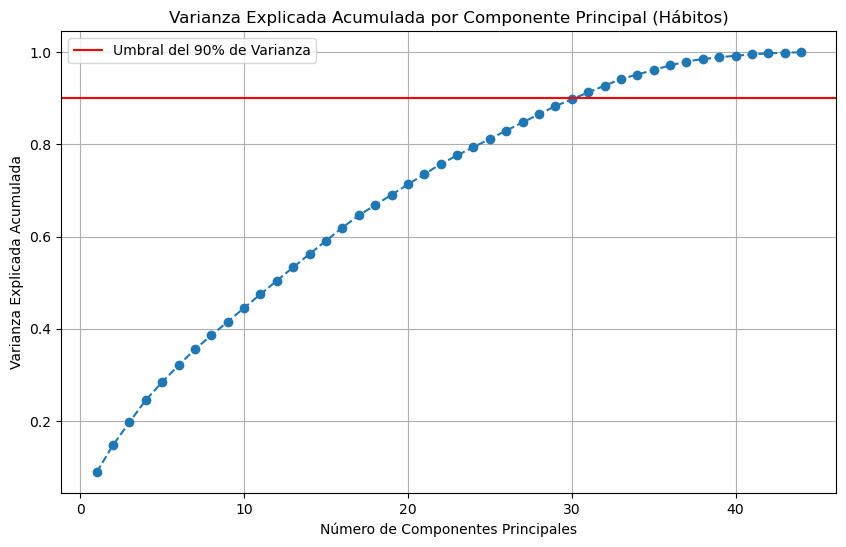


--- Resultados de PCA ---
Componentes necesarios para explicar el 90% de la varianza: 31


In [17]:
# Definición de variables clave
TARGET_COL = 'exam_score'

# 1. Preparación del DataFrame (X)
# EXCLUIMOS SOLO la variable objetivo.
X = df.drop(columns=[TARGET_COL], errors='ignore')

# 2. Identificación Automática de Columnas
# Identificamos columnas con float64 como las continuas (lo más robusto después de OHE)
CONTINUOUS_COLS = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Para ser más seguros y evitar incluir binarias que quedaron como int64/uint8, 
# Usamos la lista de 16 variables continuas que hemos validado (excluyendo exam_score y previous_gpa):
CONTINUOUS_COLS = [
    'age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
    'attendance_percentage', 'sleep_hours', 'exercise_frequency', 
    'mental_health_rating', 'semester', 'stress_level', 
    'social_activity', 'screen_time', 'parental_support_level', 
    'motivation_level', 'exam_anxiety_score', 'time_management_score'
] 

# Variables que quedan (las OHE)
BINARY_COLS = [col for col in X.columns if col not in CONTINUOUS_COLS]

print(f"✅ Variables Continuas (a escalar): {len(CONTINUOUS_COLS)}")
print(f"✅ Variables Binarias (a dejar): {len(BINARY_COLS)}")
print(f"Total de variables para PCA: {len(X.columns)}")

# 3. Aplicar RobustScaler a las columnas continuas
scaler = RobustScaler()
X_scaled_continuous = scaler.fit_transform(X[CONTINUOUS_COLS])
X_scaled_continuous_df = pd.DataFrame(X_scaled_continuous, columns=CONTINUOUS_COLS, index=X.index)

# 4. Combinar datos: Este es el DataFrame listo para PCA
X_pca = pd.concat([
    X_scaled_continuous_df, 
    X[BINARY_COLS]
], axis=1)

# --- 5. Análisis de Componentes Principales (PCA) ---
print("\n--- Aplicando PCA para determinar $k$ ---")

pca = PCA()
pca.fit(X_pca)

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# 6. Graficar el Codo (Scree Plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='Umbral del 90% de Varianza')
plt.title('Varianza Explicada Acumulada por Componente Principal (Hábitos)')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend(loc='best')
plt.grid(True)
plt.show() 

# 7. Determinar el número de componentes para el 90%
# np.argmax encuentra el primer índice donde la condición es True
n_componentes_90 = np.argmax(varianza_acumulada >= 0.90) + 1

print("\n--- Resultados de PCA ---")
print(f"Componentes necesarios para explicar el 90% de la varianza: {n_componentes_90}")

Vemos que para llegar al 90% de la varianza explicada necesitariamos 31 componentes lo que no nos reduce apenas el problema de dimensionalidad que teníamos, por lo que vamos a probar a utilizar para la construcción del PCA las variables que eran continuas antes del One-Hot.


--- Aplicando PCA solo a 16 Variables Continuas ---


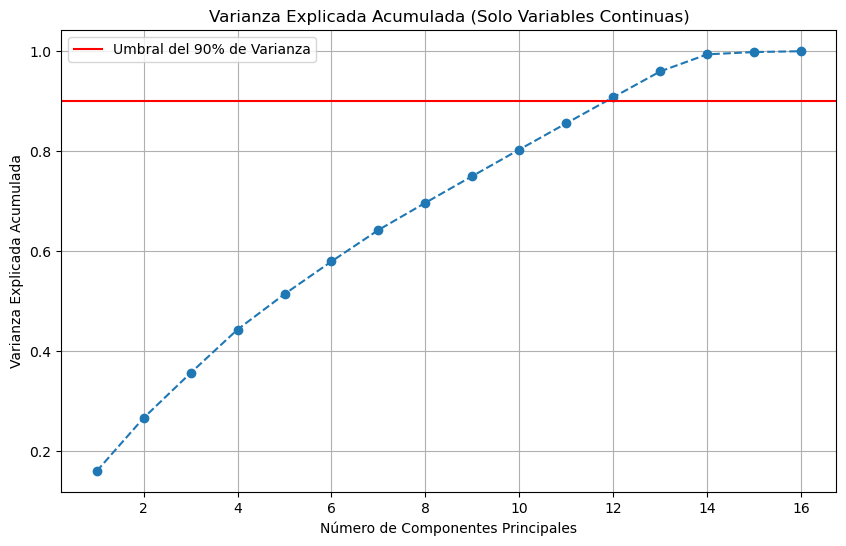


--- Resultados de PCA (Solo Continuas) ---
Componentes necesarios para explicar el 90% de la varianza: 12


In [18]:
# Asumimos que X_scaled_continuous_df es el DataFrame con las 16 variables continuas, Robust Scaled.

# --- 1. Análisis de Componentes Principales (PCA) solo con Continuas ---
print("\n--- Aplicando PCA solo a 16 Variables Continuas ---")

# Aplicamos PCA al DataFrame que SOLO contiene las variables continuas escaladas
pca_continuas = PCA()
pca_continuas.fit(X_scaled_continuous_df)

varianza_acumulada_continuas = np.cumsum(pca_continuas.explained_variance_ratio_)

# 2. Graficar el Codo (Scree Plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada_continuas) + 1), varianza_acumulada_continuas, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='Umbral del 90% de Varianza')
plt.title('Varianza Explicada Acumulada (Solo Variables Continuas)')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend(loc='best')
plt.grid(True)
plt.show() 

# 3. Determinar el número de componentes para el 90%
n_componentes_90_continuas = np.argmax(varianza_acumulada_continuas >= 0.90) + 1

print("\n--- Resultados de PCA (Solo Continuas) ---")
print(f"Componentes necesarios para explicar el 90% de la varianza: {n_componentes_90_continuas}")

Ahora vemos que efectivamente seguimos necesitando muchas para llegar a la varianza explicada del 90% pero ahora nos podemos decantar por 6 componentes que aunque no podamos gráficar en seis dimensiones ya son mas manejables y explican más de la mitad de la varianza total.

En este bloque, primero reduzco la dimensionalidad de los datos continuos escalados a 6 componentes principales como ya explicamos mediante PCA. Esto facilita el análisis de clusters al condensar la información más relevante en menos dimensiones.

Luego, para optimizar el tiempo de cómputo, creo una submuestra del 40% de los datos, esto es solamente para ganar tiempo ya que es un dataset muy grande y ajusto el K-Means solo sobre esta muestra. Esto permite explorar distintos números de clusters de manera rápida sin comprometer la calidad del análisis.

Para decidir el número óptimo de clusters, utilizo dos métodos: el codo (inercia) y el coeficiente de silueta. La inercia mide la dispersión intra-cluster, buscando un punto donde dejar de reducir significativamente mejora poco la compactación de los clusters. La silueta mide la separación relativa entre clusters; valores cercanos a 1 indican clusters bien definidos.

En resumen, este paso permite encontrar un número adecuado de clusters de manera eficiente.

--- 1. Aplicando PCA y reduciendo a 6 Componentes Principales ---
El K-Means se ajustará sobre una muestra de 32000 filas (40%) para velocidad.


  File "c:\Users\carlo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\carlo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\carlo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\carlo\anaconda3\Lib\subprocess.

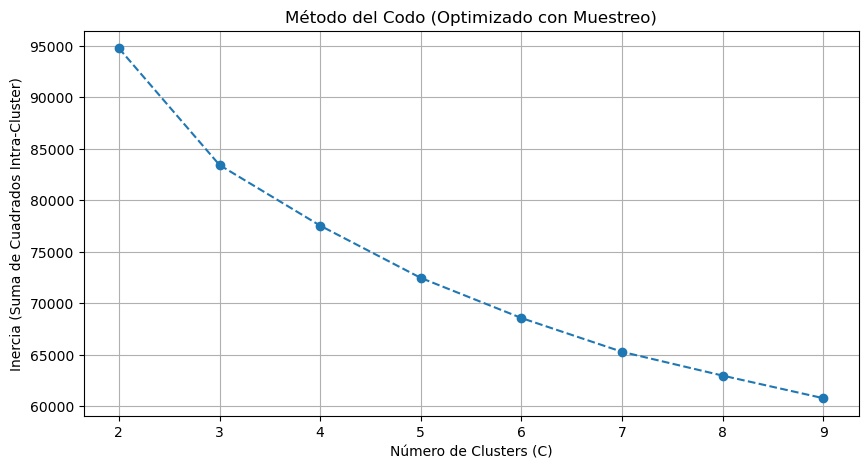

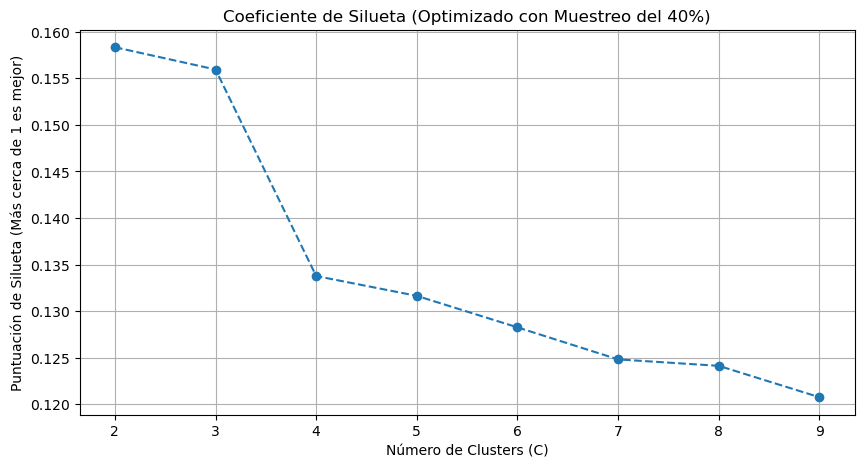

In [19]:
# Se asume que X_scaled_continuous_df es el DataFrame con las 16 variables continuas, Robust Scaled.

# --- 1. Aplicar PCA y reducir a k=6 componentes ---
K = 6 
RANGO_CLUSTERS = range(2, 10)
SAMPLE_FRAC = 0.40 # <--- ¡Muestreo del 40% para la optimización!

print(f"--- 1. Aplicando PCA y reduciendo a {K} Componentes Principales ---")

# Transformamos los datos a un espacio de 6 dimensiones (FULL DATA)
pca_final = PCA(n_components=K)
X_6D = pca_final.fit_transform(X_scaled_continuous_df)

# --- 2. Preparación de la Muestra para el Ajuste Rápido ---
# Creamos una submuestra (20%) para el ajuste de K-Means
n_samples = int(X_6D.shape[0] * SAMPLE_FRAC)
indices_muestra = np.random.choice(X_6D.shape[0], size=n_samples, replace=False)
X_sampled = X_6D[indices_muestra]

print(f"El K-Means se ajustará sobre una muestra de {n_samples} filas ({int(SAMPLE_FRAC*100)}%) para velocidad.")

# --- 3. Métodos del Codo y Silueta (Optimizado) ---
inercia = []
scores_silueta = []

for c in RANGO_CLUSTERS:
    # 1. Ajustar K-Means SOLO en la muestra (lo que hace que la ejecución sea mucho más rápida)
    kmeans = KMeans(n_clusters=c, random_state=42, n_init=10)
    kmeans.fit(X_sampled)
    
    # 2. Guardar Inercia (basada en el fit de la muestra)
    inercia.append(kmeans.inertia_)
    
    # 3. Guardar Silueta (basada en el fit de la muestra, más rápido)
    if c > 1:
        # Usamos las etiquetas de la muestra
        cluster_labels_sample = kmeans.labels_
        score = silhouette_score(X_sampled, cluster_labels_sample) 
        scores_silueta.append(score)

# --- 4. Graficación ---

# Gráfico del Codo
plt.figure(figsize=(10, 5))
plt.plot(RANGO_CLUSTERS, inercia, marker='o', linestyle='--')
plt.title('Método del Codo (Optimizado con Muestreo)')
plt.xlabel('Número de Clusters (C)')
plt.ylabel('Inercia (Suma de Cuadrados Intra-Cluster)')
plt.grid(True)
plt.show() 

# Gráfico de Silueta
plt.figure(figsize=(10, 5))
plt.plot(range(2, 10), scores_silueta, marker='o', linestyle='--') 
plt.title(f'Coeficiente de Silueta (Optimizado con Muestreo del {int(SAMPLE_FRAC*100)}%)')
plt.xlabel('Número de Clusters (C)')
plt.ylabel('Puntuación de Silueta (Más cerca de 1 es mejor)')
plt.grid(True)
plt.show()

Vemos que en cuanto al gráfico del codo no podemos decir mucho ya que no hay un codo claro pero en cuanto a la silueta si podemos ver que con 3 clusters el valor es más alto que los otros excepto 2 clusters por lo que se eligen 3 clusters para el análisis.

A continuación se muestra los valores de los componentes principales para ver que sigifica cada componente y poder interpretar asi los clusters.

In [20]:
# 1. Cargas (loadings) de las componentes
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=[f"PC{i+1}" for i in range(pca_final.n_components_)],
    index=X_scaled_continuous_df.columns
)

print("\n--- Cargas de cada variable en las 6 Componentes Principales ---")
print(loadings)

# 2. Varianza explicada
print("\n--- Varianza Explicada por Componente ---")
for i, v in enumerate(pca_final.explained_variance_ratio_):
    print(f"PC{i+1}: {v:.4f}")



--- Cargas de cada variable en las 6 Componentes Principales ---
                             PC1       PC2       PC3       PC4       PC5       PC6
age                    -0.004189  0.000770 -0.004382  0.021282 -0.012712  0.124956
study_hours_per_day     0.634770 -0.004638 -0.000995  0.000309 -0.040898  0.597198
social_media_hours      0.219960  0.001624 -0.005424 -0.005184  0.033526 -0.496483
netflix_hours           0.186648  0.005998  0.004047  0.008752  0.038572 -0.567720
attendance_percentage   0.004503 -0.001084  0.002990  0.001439 -0.012708  0.001305
sleep_hours            -0.000851 -0.002338  0.168380  0.985157 -0.021135 -0.001938
exercise_frequency     -0.001475 -0.010127 -0.011575  0.008706  0.002017  0.043414
mental_health_rating    0.002393  0.008322  0.755330 -0.115008  0.643282  0.044480
semester                0.002853 -0.003382 -0.000572  0.006258  0.006317 -0.000718
stress_level           -0.001485 -0.005943 -0.633055  0.124452  0.761693  0.051196
social_activity      

Ahora que tenemos los pesos de cada componente vemos que es lo más relevante de cada componente. 

PC1: Este componente está muy influenciado por `study_hours_per_day` (0.635) y `screen_time` (0.717). Representa un eje que captura principalmente los hábitos de estudio y tiempo frente a pantallas, diferenciando estudiantes según cuánto estudian y cuánto tiempo dedican a actividades digitales.

PC2: Aquí destacan `motivation_level` (-0.690) y `exam_anxiety_score` (0.723). Este eje refleja un contraste entre motivación y ansiedad en los exámenes, separando a los estudiantes más motivados y confiados de los más ansiosos.

PC3: Lo más relevante son `mental_health_rating` (0.755) y `stress_level` (-0.633). Este componente sintetiza el estado emocional y nivel de estrés, diferenciando a estudiantes con buena salud mental y bajo estrés de los que presentan mayor estrés y menor bienestar.


Para realizar los clusters primero utilizo los datos transformados por PCA a 6 dimensiones (X_6D) para agrupar a los estudiantes según sus hábitos y características, sin usar la variable objetivo. Defino dos algoritmos: K-Means (con 3 clusters fijos) y DBSCAN (con parámetros iniciales de densidad).

Luego, ejecuto ambos algoritmos sobre los datos y guardo las etiquetas asignadas a cada estudiante. En DBSCAN, identifico explícitamente cuántos clusters detecta y qué puntos considera ruido.

Finalmente, para interpretar los resultados, genero gráficos tridimensionales usando las tres primeras componentes principales (CP1, CP2, CP3). Esto permite visualizar cómo se agrupan los estudiantes en el espacio reducido, usando colores distintos para cada cluster. Así puedo ver patrones, solapamientos y la calidad del agrupamiento antes de usar estos clusters en los modelos predictivos.

--- Ejecutando K-Means y DBSCAN ---
--- Ejecución de Clustering completa. Visualizando en 3D... ---


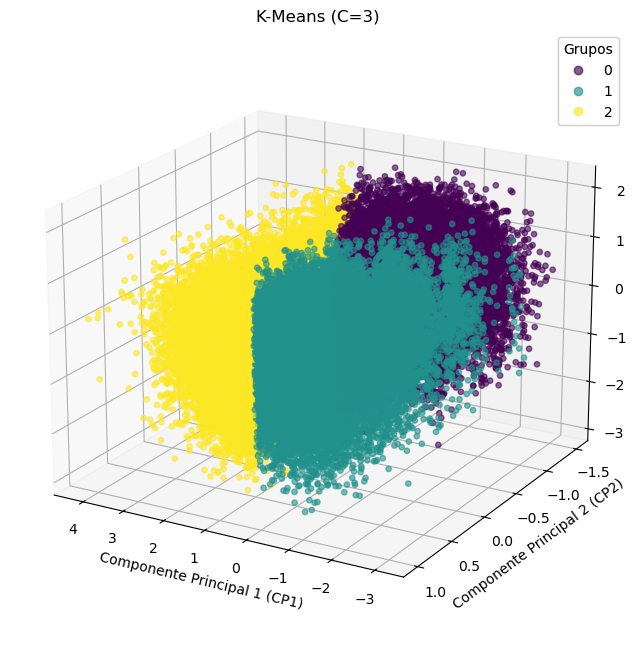

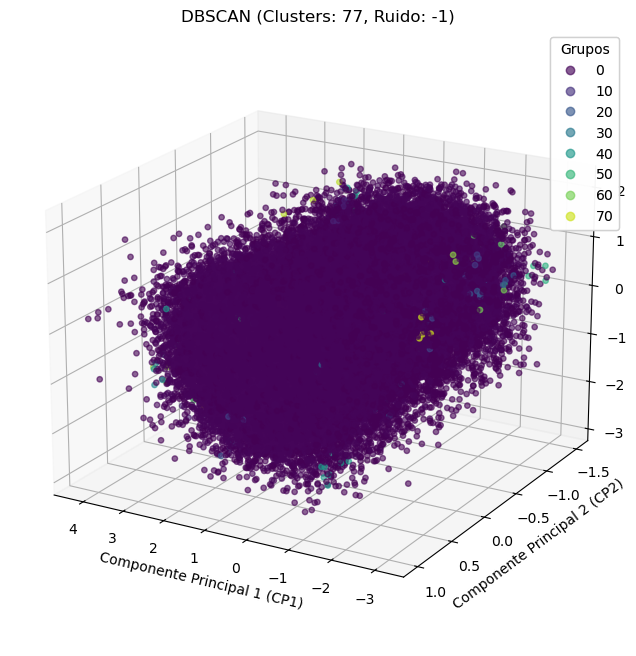

In [21]:
# Se asume que X_6D (datos PCA reducidos a 6D) está disponible.
C_fijo = 3

# Diccionario de Algoritmos (sin K-Medoids)
ALGOS = {
    "K-Means (C=3)": KMeans(n_clusters=C_fijo, random_state=42, n_init=10),
    "DBSCAN": DBSCAN(eps=0.5, min_samples=5) # Parámetros iniciales.
}

# --- 1. Ejecución de los 2 Algoritmos ---

resultados_labels = {}
print("--- Ejecutando K-Means y DBSCAN ---")

for nombre, algo in ALGOS.items():
    labels = algo.fit_predict(X_6D)
    
    if nombre == "DBSCAN":
        # Contar clusters de DBSCAN (etiqueta -1 es Ruido)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        nombre_final = f"DBSCAN (Clusters: {n_clusters}, Ruido: -1)"
    else:
        nombre_final = nombre
        
    resultados_labels[nombre_final] = labels

print("--- Ejecución de Clustering completa. Visualizando en 3D... ---")

# --- 2. Función de Visualización 3D ---

def plot_3d_clusters(data_3d, labels, title):
    """Genera un gráfico de dispersión 3D."""
    fig = plt.figure(figsize=(10, 8))
    # Especificar projection='3d' para el gráfico tridimensional
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot de los puntos
    scatter = ax.scatter(
        data_3d[:, 0], # CP1
        data_3d[:, 1], # CP2
        data_3d[:, 2], # CP3
        c=labels, 
        cmap='viridis',
        s=15, # Tamaño del punto
        alpha=0.6
    )
    
    ax.set_xlabel('Componente Principal 1 (CP1)')
    ax.set_ylabel('Componente Principal 2 (CP2)')
    ax.set_zlabel('Componente Principal 3 (CP3)')
    ax.set_title(title)

    # Añadir la leyenda de los clusters
    legend1 = ax.legend(*scatter.legend_elements(), title="Grupos")
    ax.add_artist(legend1)
    
    # Agregar una pequeña rotación inicial para mejor visualización
    ax.view_init(elev=20, azim=120) 
    plt.show()

# --- 3. Generar y Mostrar los 2 Plots ---

# Usaremos solo las tres primeras componentes (CP1, CP2, CP3) para el ploteo
X_3D = X_6D[:, :3] 

for titulo, labels in resultados_labels.items():
    plot_3d_clusters(X_3D, labels, titulo)

Lo primero que vemos es que el gráfico de DBSCAN nos muestra que no captura bien los datos ni los clusters, ya que crea 77 clusters diferents y en el mapa solo se ve una maraña de puntos ( en mi caso ) morados. En cuanto a la clasificación obtenida con k means vemos como detecta claramente tres grupos distintos que más adelante veremos que son.

In [22]:
# --- 1. Ejecución Final de K-Means (Para asegurar que tenemos las etiquetas en orden) ---
C_FINAL = 3 
print(f"--- Ejecutando K-Means final (C={C_FINAL}) para generar las etiquetas ---")

# Nota: Asumimos que X_6D fue creado con el orden de filas de df.
kmeans_final = KMeans(n_clusters=C_FINAL, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_6D)

# --- 2. Creación de la Serie de Etiquetas Indexadas ---

# Creamos una Serie de Pandas con las etiquetas generadas (el array cluster_labels).
# El paso CRUCIAL es asignar explícitamente el índice del DataFrame original (df.index).
# Esto alinea la nueva columna al DataFrame, independientemente de cualquier reordenamiento
# que pudiera haber ocurrido internamente en los arrays de NumPy.
etiquetas_serie_indexada = pd.Series(
    cluster_labels, 
    index=df.index 
)

# --- 3. Asignación Final al DataFrame Original (df) ---

# Asignamos la Serie indexada a la nueva columna del DataFrame original
df['cluster_id'] = etiquetas_serie_indexada
df['cluster_id'] = df['cluster_id'].astype('category')

print(f"\n✅ La columna 'cluster_id' se ha añadido de forma SEGURA al DataFrame original 'df'.")

# Verificación final
print("\nConteo de elementos por Cluster en el DF original:")
print(df['cluster_id'].value_counts())

--- Ejecutando K-Means final (C=3) para generar las etiquetas ---

✅ La columna 'cluster_id' se ha añadido de forma SEGURA al DataFrame original 'df'.

Conteo de elementos por Cluster en el DF original:
cluster_id
1    28848
2    27170
0    23982
Name: count, dtype: int64


Para interpretar los clusters lo que hacemos es sacar las características de los clusters para asi ver que significa cada cluster.

In [23]:
cluster_profile = df.groupby('cluster_id')[CONTINUOUS_COLS].mean()

print("\n--- Perfil de los 3 Clusters (Promedios por Variable Continua) ---")
print(cluster_profile)



--- Perfil de los 3 Clusters (Promedios por Variable Continua) ---
                  age  study_hours_per_day  social_media_hours  netflix_hours  attendance_percentage  sleep_hours  exercise_frequency  mental_health_rating  semester  stress_level  social_activity  screen_time  parental_support_level  motivation_level  exam_anxiety_score  time_management_score
cluster_id                                                                                                                                                                                                                                                                                            
0           22.016346             3.911060            2.421716       1.931665              70.022592     7.009053            3.544867              6.796768  4.498082      5.015307         2.494162     9.257743                5.447669          8.794846            6.205154               5.524902
1           22.038096             2.838297     

Vemos que podría describirse así cada cluster basándonos en los promedios:

Cluster 0: Estudiantes con hábitos intermedios: estudian unas 4 horas al día, usan redes sociales y Netflix de forma moderada, tienen asistencia promedio al aula (70%) y un nivel de motivación relativamente alto.

Cluster 1: Estudiantes que dedican menos horas al estudio (2.8 h/día) y consumen menos medios, pero muestran mayor ansiedad en los exámenes y motivación más baja.

Cluster 2: Estudiantes más dedicados al estudio (5.8 h/día) y con mayor tiempo frente a pantallas, aunque la asistencia y motivación son similares a los otros clusters; destacan por un equilibrio entre estudio y ocio, pero con ansiedad moderada.

# FASE 2

En esta segunda fase paso de la parte descriptiva a la parte estrictamente predictiva. Tras haber reducido la dimensionalidad y obtenido grupos homogéneos de estudiantes mediante clustering, el objetivo de esta fase es construir modelos capaces de predecir el rendimiento académico (exam_score) a partir del conjunto de variables disponibles.

Para ello planteo dos enfoques complementarios. El primero es un modelo global, donde entreno algoritmos como árboles de decisión, métodos de boosting (XGBoost, LightGBM o Gradient Boosting) y una red neuronal tomando toda la muestra completa sin distinguir entre clusters. Este enfoque permite evaluar la capacidad general de cada técnica para capturar relaciones entre las variables y el desempeño académico.

El segundo enfoque consiste en aplicar un modelo independiente por cada cluster, aprovechando que los grupos definidos en la fase anterior representan perfiles de estudiantes con comportamientos y patrones similares. Esta estrategia busca comprobar si modelos especializados pueden mejorar la capacidad predictiva al adaptarse mejor a la estructura interna de cada cluster, para ello compararemos el R2 de los modelos que nos salgan para ver si hemos obtenido una ganancia al realizar un diferente método por cluster.

En este bloque preparo los datos para el enfoque de modelos por cluster. Básicamente, separo el dataset en subconjuntos según el `cluster_id` y, para cada cluster, divido los datos en entrenamiento y test. Esto me permite entrenar un modelo independiente para cada grupo de estudiantes y evaluar su rendimiento en un test reservado, asegurando que la predicción se ajuste al perfil específico de cada cluster. Además, guardar estos subconjuntos en un diccionario facilita manejar los distintos modelos de manera organizada.

In [24]:
# Definir la variable objetivo
TARGET = 'exam_score'

# Diccionario para guardar los conjuntos de train/test por cluster
data_por_cluster = {}

for c in df['cluster_id'].cat.categories:
    df_c = df[df['cluster_id'] == c].copy()
    
    # Separar X e y
    X = df_c.drop(columns=[TARGET, 'cluster_id'])
    y = df_c[TARGET]
    
    # Submuestra para test (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    data_por_cluster[c] = (X_train, X_test, y_train, y_test)
    
print("✅ Datos separados por cluster y submuestra de test listas.")


✅ Datos separados por cluster y submuestra de test listas.


En este otro bloque se preparan los datos para el enfoque global, es decir, entrenar un único modelo sobre todos los estudiantes sin distinguir clusters. Separamos las variables predictoras de la variable objetivo exam_score y luego creamos un conjunto de entrenamiento y otro de prueba, reservando un 20% para test. Esto permite evaluar el modelo final sobre datos que no ha visto durante el entrenamiento y comparar su rendimiento con los modelos que se entrenarán por cluster.

In [25]:
TARGET = 'exam_score'

# Variables predictoras (excluyendo target y cluster_id)
X_global = df.drop(columns=[TARGET, 'cluster_id'])
y_global = df[TARGET]

# Submuestra para test (20%)
X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_global, y_global, test_size=0.2, random_state=42
)

print("✅ Datos globales separados en train/test")
print(f"X_train: {X_train_global.shape}, X_test: {X_test_global.shape}")


✅ Datos globales separados en train/test
X_train: (64000, 44), X_test: (16000, 44)


En este bloque de código se realiza el entrenamiento y evaluación de dos modelos globales para predecir la variable `exam_score`, considerando todos los datos sin separar por clusters. Primero, se define un pipeline para un árbol de decisión que incluye un escalado robusto de las variables continuas, lo que permite que el modelo no se vea afectado por valores extremos. Luego, se define un conjunto de hiperparámetros para explorar distintas configuraciones del árbol, como la profundidad máxima y el número mínimo de muestras por nodo. La búsqueda del mejor conjunto de parámetros se realiza mediante GridSearchCV utilizando validación cruzada de 6 folds, asegurando que el modelo se ajuste de manera generalizable y no solo al conjunto de entrenamiento.

De manera similar, se define un pipeline para un Random Forest, que combina múltiples árboles para mejorar la estabilidad y precisión de la predicción. Dado que Random Forest es más costoso computacionalmente, se usa RandomizedSearchCV con un número limitado de combinaciones y un conjunto de hiperparámetros reducido, lo que permite explorar distintas configuraciones sin que el tiempo de entrenamiento sea excesivo. Ambos modelos, una vez entrenados y optimizados, se aplican al conjunto de test global, calculando el coeficiente de determinación R² como métrica de desempeño. Esto nos da una línea base de cuán bien predicen los modelos los resultados de los estudiantes cuando se utiliza un único modelo global para todos los datos, antes de pasar a comparar con la estrategia de modelos específicos por cluster.

In [26]:
# Definimos K-Fold
kf = KFold(n_splits=6, shuffle=True, random_state=42)


In [27]:
# Pipeline Decision Tree
pipe_dt = Pipeline([
    ('scaler', RobustScaler()),  # Escalado
    ('model', DecisionTreeRegressor(random_state=42))
])

# Hiperparámetros a probar
param_grid_dt = {
    'model__max_depth': [None, 5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# GridSearchCV con K-Fold
gs_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=kf, scoring='r2', n_jobs=-1)
gs_dt.fit(X_train_global, y_train_global)

# Mejor modelo
best_dt = gs_dt.best_estimator_
print("✅ Mejor Decision Tree entrenado")
print("Mejores hiperparámetros:", gs_dt.best_params_)


✅ Mejor Decision Tree entrenado
Mejores hiperparámetros: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}


In [28]:
# Pipeline Random Forest
pipe_rf = Pipeline([
    ('scaler', RobustScaler()),  # Escalado
    ('model', RandomForestRegressor(random_state=42))
])

# Hiperparámetros reducidos para menor tiempo
param_dist_rf = {
    'model__n_estimators': [50, 100],         # menos árboles
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# RandomizedSearchCV con pocas combinaciones
rs_rf = RandomizedSearchCV(
    pipe_rf, 
    param_distributions=param_dist_rf,
    n_iter=6,              # número de combinaciones a probar
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# Entrenar
rs_rf.fit(X_train_global, y_train_global)

# Mejor modelo
best_rf = rs_rf.best_estimator_
print("✅ Mejor Random Forest entrenado")
print("Mejores hiperparámetros:", rs_rf.best_params_)


✅ Mejor Random Forest entrenado
Mejores hiperparámetros: {'model__n_estimators': 50, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 10}


In [29]:
# Decision Tree
y_pred_dt = best_dt.predict(X_test_global)
r2_dt = r2_score(y_test_global, y_pred_dt)

# Random Forest
y_pred_rf = best_rf.predict(X_test_global)
r2_rf = r2_score(y_test_global, y_pred_rf)

print("\n--- Resultados en Test Set Global ---")
print(f"Decision Tree R²: {r2_dt:.4f}")
print(f"Random Forest R²: {r2_rf:.4f}")



--- Resultados en Test Set Global ---
Decision Tree R²: 0.1461
Random Forest R²: 0.1858


Los resultados obtenidos de la métrica del R2 son los que nos muestra este último codigo, vemos como en general es un R2 bajo y como el Random forest tiene un R2 superior al del árbol de decisión. Para buscar otro modelo que pudiera superar estos R2 nos decantamos por el Gradient Boosting para el que realizamos el mismo proceso con los correspondientes hiperparámetros.

In [30]:
# --- 1. Pipeline Gradient Boosting ---
pipe_gbr = Pipeline([
    ('scaler', RobustScaler()),  # Escalado
    ('model', GradientBoostingRegressor(random_state=31))
])

# --- 2. Hiperparámetros para RandomizedSearch ---
param_distributions = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# --- 3. Submuestra para búsqueda (40%) ---
sample_frac = 0.4
idx_sample = np.random.choice(X_train_global.shape[0], size=int(X_train_global.shape[0]*sample_frac), replace=False)
X_sample = X_train_global.iloc[idx_sample]
y_sample = y_train_global.iloc[idx_sample]

# --- 4. RandomizedSearchCV ---
n_iter_search = 10  # Solo 10 combinaciones
cv_folds = 3        # CV reducido para velocidad
random_search = RandomizedSearchCV(
    pipe_gbr,
    param_distributions,
    n_iter=n_iter_search,
    cv=cv_folds,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# Ajustamos solo en la submuestra
random_search.fit(X_sample, y_sample)
print("✅ RandomizedSearchCV terminado")
print("Mejores hiperparámetros encontrados:", random_search.best_params_)

# --- 5. Entrenar modelo final completo con mejores hiperparámetros ---
best_params = random_search.best_params_
final_gbr = Pipeline([
    ('scaler', RobustScaler()),
    ('model', GradientBoostingRegressor(
        random_state=42,
        n_estimators=best_params['model__n_estimators'],
        max_depth=best_params['model__max_depth'],
        learning_rate=best_params['model__learning_rate'],
        min_samples_split=best_params['model__min_samples_split'],
        min_samples_leaf=best_params['model__min_samples_leaf']
    ))
])

final_gbr.fit(X_train_global, y_train_global)
r2_test = final_gbr.score(X_test_global, y_test_global)
print(f"\n✅ Gradient Boosting final entrenado en todos los datos de train")
print(f"R² en Test Set Global: {r2_test:.4f}")


✅ RandomizedSearchCV terminado
Mejores hiperparámetros encontrados: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__learning_rate': 0.1}

✅ Gradient Boosting final entrenado en todos los datos de train
R² en Test Set Global: 0.1960


Vemos que de momento es el mejor R2 que hemos obtenido con el método global, por lo tanto querremos ver si alguno de nuestros modelos de cluster supera ese R2 de 0,1960

Ahora vamos a pasar al método por clusters, en este bloque entreno un árbol de decisión diferente para cada cluster usando validación cruzada con GridSearchCV para encontrar los mejores hiperparámetros. Luego, cada modelo predice sobre su conjunto de test correspondiente y se combinan todas las predicciones para calcular un R² global. De esta manera evaluamos el desempeño conjunto de los modelos específicos por cluster en lugar de un único modelo global.

In [31]:
# --- 1. Definir K-Fold para cross-validation ---
kf = KFold(n_splits=6, shuffle=True, random_state=42)

# --- 2. Diccionario para guardar los mejores modelos por cluster ---
modelos_por_cluster = {}

# --- 3. Hiperparámetros a probar ---
param_grid_dt = {
    'model__max_depth': [None,1,2, 3, 5, 7],
    'model__min_samples_split': [2 ,3,4, 5, 7, 10],
    'model__min_samples_leaf': [1, 2, 4, 6]
}

# --- 4. Entrenamiento por cluster ---
for c in df['cluster_id'].cat.categories:
    X_train, X_test, y_train, y_test = data_por_cluster[c]
    
    # Pipeline: escalado + Árbol
    pipe_dt = Pipeline([
        ('scaler', RobustScaler()),
        ('model', DecisionTreeRegressor(random_state=42))
    ])
    
    # GridSearchCV para este cluster
    gs = GridSearchCV(pipe_dt, param_grid_dt, cv=kf, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)
    
    # Guardamos el mejor modelo
    modelos_por_cluster[c] = gs.best_estimator_
    
    print(f"✅ Cluster {c}: Mejor Árbol entrenado con R² CV = {gs.best_score_:.3f}")

# --- 5. Predicciones sobre los test sets y unión ---
y_test_global = []
y_pred_global = []

for c in df['cluster_id'].cat.categories:
    X_train, X_test, y_train, y_test = data_por_cluster[c]
    modelo = modelos_por_cluster[c]
    
    y_pred = modelo.predict(X_test)
    
    y_test_global.append(y_test)
    y_pred_global.append(y_pred)

# Convertimos a arrays concatenados
y_test_global = np.concatenate([y.values for y in y_test_global])
y_pred_global = np.concatenate(y_pred_global)

# --- 6. R² global ---
r2_global = r2_score(y_test_global, y_pred_global)
print(f"\n--- R² global usando modelos por cluster: {r2_global:.3f} ---")


✅ Cluster 0: Mejor Árbol entrenado con R² CV = 0.090
✅ Cluster 1: Mejor Árbol entrenado con R² CV = 0.075
✅ Cluster 2: Mejor Árbol entrenado con R² CV = 0.094

--- R² global usando modelos por cluster: 0.150 ---


Observamos que el R2 global es de 0,15. También apreciamos que el R² individual por cluster es bajo porque cada modelo ve menos datos y la relación entre variables y `exam_score` es débil dentro de cada grupo. Sin embargo, al combinar las predicciones de los tres clusters, el R² global mejora, reflejando que los modelos capturan algo de patrón general aunque limitado.

En esta fase aplicamos Random Forest siguiendo la misma lógica que usamos con los árboles de decisión, pero aprovechando la capacidad de este modelo para manejar relaciones más complejas y reducir el sobreajuste mediante el ensamblado de múltiples árboles. Primero buscamos los mejores hiperparámetros usando solo una submuestra del 40% de los datos de cada cluster para ahorrar tiempo, luego entrenamos cada modelo con todo el conjunto de entrenamiento del cluster y finalmente combinamos las predicciones para obtener un R² global. Esto nos permite comparar directamente si usar un modelo por cluster mejora la predicción frente a un modelo global único.

In [32]:
# -----------------------------
# Parámetros generales
# -----------------------------
TARGET = 'exam_score'
SAMPLE_FRAC = 0.4  # 40% de los datos para buscar hiperparámetros
N_ITER = 10        # Número de combinaciones aleatorias en RandomizedSearchCV
KFOLD = 6

# Diccionarios para guardar resultados
modelos_rf_por_cluster = {}
r2_por_cluster = {}

# -----------------------------
# Loop por cluster
# -----------------------------
for c in df['cluster_id'].cat.categories:
    print(f"\n--- Cluster {c} ---")
    
    # Datos del cluster
    df_c = df[df['cluster_id'] == c].copy()
    X = df_c.drop(columns=[TARGET, 'cluster_id'])
    y = df_c[TARGET]
    
    # Submuestra para test (20%)
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Submuestra del 40% de train para RandomizedSearch
    n_sample = int(X_train.shape[0] * SAMPLE_FRAC)
    idx_sample = np.random.choice(X_train.index, size=n_sample, replace=False)
    X_train_sample = X_train.loc[idx_sample]
    y_train_sample = y_train.loc[idx_sample]
    
    # -----------------------------
    # Pipeline y RandomizedSearchCV
    # -----------------------------
    pipe_rf = Pipeline([
        ('scaler', RobustScaler()),
        ('model', RandomForestRegressor(random_state=42))
    ])
    
    param_dist_rf = {
        'model__n_estimators': [50, 75, 100, 125, 150, 200],
        'model__max_depth': [None, 2, 3,  5, 7,10, 15],
        'model__min_samples_split': [2, 5, 7, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }
    
    rs_rf = RandomizedSearchCV(pipe_rf, param_distributions=param_dist_rf, 
                               n_iter=N_ITER, cv=KFOLD, scoring='r2', n_jobs=-1, random_state=42)
    
    # Ajuste solo sobre la submuestra
    rs_rf.fit(X_train_sample, y_train_sample)
    print("Mejores hiperparámetros:", rs_rf.best_params_)
    
    # -----------------------------
    # Entrenar modelo final con hiperparámetros óptimos
    # -----------------------------
    # Extraer solo los parámetros del modelo
    best_params_model = {k.replace('model__',''): v for k,v in rs_rf.best_params_.items()}
    
    # Pipeline final
    best_rf = Pipeline([
        ('scaler', RobustScaler()),
        ('model', RandomForestRegressor(**best_params_model, random_state=42))
    ])
    
    # Entrenar con todo el train del cluster
    best_rf.fit(X_train, y_train)
    
    # Guardar modelo
    modelos_rf_por_cluster[c] = best_rf
    
    # Evaluar en test del cluster
    y_pred = best_rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_por_cluster[c] = r2
    print(f"R2 en test del cluster {c}: {r2:.4f}")

# -----------------------------
# Evaluación final global
# -----------------------------
# Predecir usando cada modelo según su cluster
y_true_global = []
y_pred_global = []

for c in df['cluster_id'].cat.categories:
    df_c = df[df['cluster_id'] == c].copy()
    X_c = df_c.drop(columns=[TARGET, 'cluster_id'])
    y_c = df_c[TARGET]
    
    y_c_pred = modelos_rf_por_cluster[c].predict(X_c)
    
    y_true_global.extend(y_c)
    y_pred_global.extend(y_c_pred)

# R2 global
r2_global = r2_score(y_true_global, y_pred_global)
print(f"\n✅ R2 global combinando los modelos por cluster: {r2_global:.4f}")



--- Cluster 0 ---
Mejores hiperparámetros: {'model__n_estimators': 200, 'model__min_samples_split': 7, 'model__min_samples_leaf': 1, 'model__max_depth': 7}
R2 en test del cluster 0: 0.1436

--- Cluster 1 ---
Mejores hiperparámetros: {'model__n_estimators': 200, 'model__min_samples_split': 7, 'model__min_samples_leaf': 1, 'model__max_depth': 7}
R2 en test del cluster 1: 0.1190

--- Cluster 2 ---
Mejores hiperparámetros: {'model__n_estimators': 200, 'model__min_samples_split': 7, 'model__min_samples_leaf': 1, 'model__max_depth': 7}
R2 en test del cluster 2: 0.1163

✅ R2 global combinando los modelos por cluster: 0.2321


Obtenemos un R2 global de 0,2321.

A continuación repetimos el proceso con gradient boosting buscando superar el R2 anterior.

In [33]:
# Definición
TARGET = 'exam_score'
n_iter_search = 20  # Menos iteraciones para acelerar
SAMPLE_FRAC = 0.4   # 40% de la muestra para búsqueda

# Diccionario para guardar modelos finales
modelos_gbr_por_cluster = {}

# Lista para guardar predicciones y verdad
y_test_global = []
y_pred_global = []

# K-Fold para búsqueda
kf = KFold(n_splits=6, shuffle=True, random_state=42)

for c in df['cluster_id'].cat.categories:
    print(f"\n--- Cluster {c} ---")
    
    X_train, X_test, y_train, y_test = data_por_cluster[c]
    
    # Submuestra para RandomizedSearchCV
    n_samples = int(X_train.shape[0] * SAMPLE_FRAC)
    idx_subsample = np.random.choice(X_train.index, size=n_samples, replace=False)
    X_sub = X_train.loc[idx_subsample]
    y_sub = y_train.loc[idx_subsample]
    
    # Pipeline
    pipe_gbr = Pipeline([
        ('scaler', RobustScaler()),
        ('model', GradientBoostingRegressor(random_state=42))
    ])
    
    # Parámetros a buscar
    param_dist = {
        'model__n_estimators': [50, 75, 100, 125, 150, 200, 250],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [1, 3, 5, 7],
        'model__min_samples_split': [2, 3, 5, 7,10],
        'model__min_samples_leaf': [1, 2, 4, 7]
    }
    
    # RandomizedSearchCV
    rs_gbr = RandomizedSearchCV(pipe_gbr, param_distributions=param_dist,
                                n_iter=n_iter_search, cv=kf, scoring='r2', n_jobs=-1, random_state=42)
    
    rs_gbr.fit(X_sub, y_sub)
    
    print(f"✅ Cluster {c}: Mejor Gradient Boosting entrenado")
    print("Mejores hiperparámetros:", rs_gbr.best_params_)
    
    # Entrenar modelo final sobre todo el train del cluster con los mejores hiperparámetros
    best_gbr = Pipeline([
        ('scaler', RobustScaler()),
        ('model', GradientBoostingRegressor(
            n_estimators=rs_gbr.best_params_['model__n_estimators'],
            learning_rate=rs_gbr.best_params_['model__learning_rate'],
            max_depth=rs_gbr.best_params_['model__max_depth'],
            min_samples_split=rs_gbr.best_params_['model__min_samples_split'],
            min_samples_leaf=rs_gbr.best_params_['model__min_samples_leaf'],
            random_state=42
        ))
    ])
    best_gbr.fit(X_train, y_train)
    
    modelos_gbr_por_cluster[c] = best_gbr
    
    # Predicciones para test global
    y_test_global.append(y_test)
    y_pred_global.append(best_gbr.predict(X_test))

# Concatenar todos los test
y_test_concat = np.concatenate(y_test_global)
y_pred_concat = np.concatenate(y_pred_global)

# R² global
r2_global = r2_score(y_test_concat, y_pred_concat)
print(f"\n--- R² global usando Gradient Boosting por cluster: {r2_global:.3f} ---")



--- Cluster 0 ---
✅ Cluster 0: Mejor Gradient Boosting entrenado
Mejores hiperparámetros: {'model__n_estimators': 75, 'model__min_samples_split': 7, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__learning_rate': 0.1}

--- Cluster 1 ---
✅ Cluster 1: Mejor Gradient Boosting entrenado
Mejores hiperparámetros: {'model__n_estimators': 75, 'model__min_samples_split': 7, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__learning_rate': 0.1}

--- Cluster 2 ---
✅ Cluster 2: Mejor Gradient Boosting entrenado
Mejores hiperparámetros: {'model__n_estimators': 75, 'model__min_samples_split': 7, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__learning_rate': 0.1}

--- R² global usando Gradient Boosting por cluster: 0.197 ---


El R2 global es de 0,197

Seguidamente probamos el método de XGBoost para seguir buscando el modelo que nos proporcione mejor R2.

In [34]:
# Definir la variable objetivo
TARGET = 'exam_score'

# Crear diccionario para guardar los modelos por cluster
modelos_xgb_por_cluster = {}

# Crear diccionario para test sets por cluster
test_sets_por_cluster = {}

# Definir KFold para CV
kf = KFold(n_splits=6, shuffle=True, random_state=42)

# Proporción de submuestra para RandomizedSearch
SAMPLE_FRAC = 0.40

# Iterar sobre los clusters
for c in df['cluster_id'].cat.categories:
    print(f"\n--- Cluster {c} ---")
    df_c = df[df['cluster_id'] == c].copy()
    
    # Separar X e y
    X = df_c.drop(columns=[TARGET, 'cluster_id'])
    y = df_c[TARGET]
    
    # Separar test set final (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    test_sets_por_cluster[c] = (X_test, y_test)
    
    # Submuestra para búsqueda de hiperparámetros
    n_samples = int(X_train.shape[0] * SAMPLE_FRAC)
    idx_sub = np.random.choice(X_train.shape[0], size=n_samples, replace=False)
    X_sub = X_train.iloc[idx_sub]
    y_sub = y_train.iloc[idx_sub]
    
    # Pipeline con escalado y XGBoost
    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('model', XGBRegressor(random_state=42, objective='reg:squarederror'))
    ])
    
    # Hiperparámetros a explorar
    param_dist = {
        'model__n_estimators': [50, 75, 100, 125, 150, 200, 300],
        'model__max_depth': [3, 5, 6, 7, 9, 11],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.85, 1.0],
        'model__colsample_bytree': [0.5, 0.7, 0.8, 0.85, 1.0],
        'model__gamma': [0, 0.1, 0.15, 0.2]
    }
    
    # RandomizedSearchCV
    rs = RandomizedSearchCV(
        pipe, param_distributions=param_dist, n_iter=10, cv=kf,
        scoring='r2', n_jobs=-1, random_state=42, verbose=0
    )
    
    # Ajustar sobre submuestra
    rs.fit(X_sub, y_sub)
    
    print("Mejores hiperparámetros:", rs.best_params_)
    
    # Entrenar modelo final con hiperparámetros encontrados sobre todo X_train
    best_xgb = Pipeline([
        ('scaler', RobustScaler()),
        ('model', XGBRegressor(
            n_estimators=rs.best_params_['model__n_estimators'],
            max_depth=rs.best_params_['model__max_depth'],
            learning_rate=rs.best_params_['model__learning_rate'],
            subsample=rs.best_params_['model__subsample'],
            colsample_bytree=rs.best_params_['model__colsample_bytree'],
            gamma=rs.best_params_['model__gamma'],
            random_state=42,
            objective='reg:squarederror'
        ))
    ])
    
    best_xgb.fit(X_train, y_train)
    
    modelos_xgb_por_cluster[c] = best_xgb
    print(f"✅ Cluster {c}: Mejor XGBoost entrenado")

# --- Evaluación global combinando clusters ---
y_true_global = []
y_pred_global = []

for c in df['cluster_id'].cat.categories:
    X_test, y_test = test_sets_por_cluster[c]
    model = modelos_xgb_por_cluster[c]
    
    y_pred = model.predict(X_test)
    
    y_true_global.extend(y_test)
    y_pred_global.extend(y_pred)

r2_global = r2_score(y_true_global, y_pred_global)
print(f"\n--- R² global usando modelos XGBoost por cluster: {r2_global:.3f} ---")



--- Cluster 0 ---
Mejores hiperparámetros: {'model__subsample': 0.85, 'model__n_estimators': 75, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.85}
✅ Cluster 0: Mejor XGBoost entrenado

--- Cluster 1 ---
Mejores hiperparámetros: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 9, 'model__learning_rate': 0.01, 'model__gamma': 0.15, 'model__colsample_bytree': 0.5}
✅ Cluster 1: Mejor XGBoost entrenado

--- Cluster 2 ---
Mejores hiperparámetros: {'model__subsample': 0.85, 'model__n_estimators': 75, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.85}
✅ Cluster 2: Mejor XGBoost entrenado

--- R² global usando modelos XGBoost por cluster: 0.188 ---


El R2 global obtenido es de 0,189.

Ahora toca centrarnos en redes neuronales. Hasta ahora hemos probado modelos de árbol y boosting, pero en esta etapa queremos explorar cómo una red neuronal puede capturar relaciones más complejas entre las variables, incluyendo interacciones no lineales que los modelos anteriores podrían haber pasado por alto. Vamos a entrenar primero un modelo global con todos los datos, para tener una referencia general, y después podremos considerar modelos por cluster si queremos adaptar la red a los distintos perfiles de estudiantes que identificamos previamente. Esto nos permitirá evaluar si la segmentación aporta mejoras significativas o si la red global ya es suficiente para capturar las tendencias principales

In [35]:
# --------------------------
# 1. Preparar los datos
# --------------------------
TARGET = 'exam_score'

# X: todas las columnas menos la target y cluster_id
X = df.drop(columns=[TARGET, 'cluster_id'])
y = df[TARGET]

# Escalar las variables
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --------------------------
# 2. Definir la red neuronal
# --------------------------
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Regresión: salida 1, lineal
])

# Compilar
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping para no sobreentrenar
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# --------------------------
# 3. Entrenamiento
# --------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,  # Para ver cómo va durante entrenamiento
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# --------------------------
# 4. Evaluación
# --------------------------
y_pred = model.predict(X_test).flatten()
r2 = r2_score(y_test, y_pred)
print(f"\n✅ R² en Test Set: {r2:.3f}")


Epoch 1/50


c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)


   1/1600 ━━━━━━━━━━━━━━━━━━━━ 26:59 1s/step - loss: 8285.3281 - mae: 90.2123

c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)


1567/1600 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1737.3582 - mae: 28.9567

c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)


1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 586.2251 - mae: 15.9191 - val_loss: 138.1407 - val_mae: 9.5852
Epoch 2/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 119.7026 - mae: 8.9341 - val_loss: 115.6303 - val_mae: 9.0174
Epoch 3/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 111.7162 - mae: 8.6510 - val_loss: 111.5476 - val_mae: 8.7152
Epoch 4/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 110.6266 - mae: 8.6051 - val_loss: 112.1058 - val_mae: 8.7054
Epoch 5/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 110.0810 - mae: 8.5811 - val_loss: 111.9705 - val_mae: 8.6399
Epoch 6/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 109.5724 - mae: 8.5651 - val_loss: 111.3388 - val_mae: 8.7720
Epoch 7/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 109.4612 - mae: 8.5634 - val_loss: 111.2398 - val_mae: 8.7442
Epoch 8/50
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 108.9975 - mae: 8.5360 - val_loss: 117.3968 - val_mae: 9.1850
Epoch 9/50
1600/16

El R2 con el modo global es de 0,184. Ahora probamos el diferenciado por clusters, este código entrena una red neuronal independiente para cada cluster de estudiantes, usando solo los datos de ese grupo. Cada modelo aprende patrones específicos del cluster, en lugar de intentar generalizar sobre todos los estudiantes. Luego se combinan las predicciones de todos los clusters para obtener un R² global, es decir, lo que llevamos haciendo durante toda la práctica pero con redes ahora.

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --------------------------
# Definir objetivo
# --------------------------
TARGET = 'exam_score'

# Diccionario para guardar modelos y test sets
modelos_nn_por_cluster = {}
X_test_por_cluster = {}
y_test_por_cluster = {}

# Parámetros generales
EPOCHS = 100
BATCH_SIZE = 16
KFOLD = 5
EARLY_STOP = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Iterar por cada cluster
for c in df['cluster_id'].cat.categories:
    df_c = df[df['cluster_id'] == c].copy()
    
    # Separar X e y
    X = df_c.drop(columns=[TARGET, 'cluster_id'])
    y = df_c[TARGET]
    
    # Escalado
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Submuestra test (20%)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    
    # Guardar test para evaluación global después
    X_test_por_cluster[c] = X_test
    y_test_por_cluster[c] = y_test
    
    # --- Crear la red neuronal ---
    input_dim = X_train.shape[1]
    model = Sequential([
        Dense(32, input_dim=input_dim, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)  # salida continua
    ])
    
    model.compile(optimizer='adam', loss='mse')
    
    # --- K-Fold Cross-Validation (opcional, para estabilidad) ---
    kf = KFold(n_splits=KFOLD, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0,
                  callbacks=[EARLY_STOP])
    
    # Guardar el modelo entrenado por cluster
    modelos_nn_por_cluster[c] = (model, scaler)
    print(f"✅ Cluster {c}: Red neuronal entrenada con {X_train.shape[0]} filas de train")

# --- Evaluación global ---
y_true_global = []
y_pred_global = []

for c in df['cluster_id'].cat.categories:
    model, scaler = modelos_nn_por_cluster[c]
    X_test = X_test_por_cluster[c]
    y_test = y_test_por_cluster[c]
    
    y_pred = model.predict(X_test).flatten()
    
    y_true_global.extend(y_test)
    y_pred_global.extend(y_pred)

r2_global = r2_score(y_true_global, y_pred_global)
print(f"\n--- R² global usando modelos de red neuronal por cluster: {r2_global:.3f} ---")



c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)


✅ Cluster 0: Red neuronal entrenada con 19185 filas de train


c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)


✅ Cluster 1: Red neuronal entrenada con 23078 filas de train


c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)


✅ Cluster 2: Red neuronal entrenada con 21736 filas de train
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

--- R² global usando modelos de red neuronal por cluster: 0.185 ---


El R2 obtenido es de 0,169.

Para tratar de mejorar la predicción incluimos:

Capas más profundas y más neuronas para capturar relaciones complejas.

BatchNormalization para estabilizar y acelerar el entrenamiento.

Dropout para reducir overfitting (0.3 y 0.2).

ReduceLROnPlateau para disminuir learning rate si la validación se estanca.

K-Fold dentro de cada cluster para mejorar la robustez del entrenamiento.

In [37]:
# Parámetros generales
TARGET = 'exam_score'
EPOCHS = 100
BATCH_SIZE = 32
KFOLD = 5

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# Diccionarios para guardar modelos y test sets
modelos_nn_por_cluster = {}
X_test_por_cluster = {}
y_test_por_cluster = {}

for c in df['cluster_id'].cat.categories:
    print(f"\n--- Entrenando red neuronal para Cluster {c} ---")
    
    df_c = df[df['cluster_id'] == c].copy()
    X = df_c.drop(columns=[TARGET, 'cluster_id'])
    y = df_c[TARGET]
    
    # Escalado
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    X_test_por_cluster[c] = X_test
    y_test_por_cluster[c] = y_test
    
    # Crear modelo optimizado
    input_dim = X_train.shape[1]
    model = Sequential([
        Dense(128, input_dim=input_dim, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # K-Fold Cross-Validation
    kf = KFold(n_splits=KFOLD, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr,
                  validation_data=(X_val, y_val),
                  epochs=EPOCHS,
                  batch_size=BATCH_SIZE,
                  verbose=0,
                  callbacks=[early_stop, reduce_lr])
    
    modelos_nn_por_cluster[c] = (model, scaler)
    print(f"✅ Cluster {c}: Red neuronal entrenada con {X_train.shape[0]} filas de train")

# Evaluación global
y_true_global = []
y_pred_global = []

for c in df['cluster_id'].cat.categories:
    model, scaler = modelos_nn_por_cluster[c]
    X_test = X_test_por_cluster[c]
    y_test = y_test_por_cluster[c]
    
    y_pred = model.predict(X_test).flatten()
    
    y_true_global.extend(y_test)
    y_pred_global.extend(y_pred)

r2_global = r2_score(y_true_global, y_pred_global)
print(f"\n--- R² global usando modelos de red neuronal por cluster: {r2_global:.3f} ---")



--- Entrenando red neuronal para Cluster 0 ---


c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing cop

✅ Cluster 0: Red neuronal entrenada con 19185 filas de train

--- Entrenando red neuronal para Cluster 1 ---


c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing cop

✅ Cluster 1: Red neuronal entrenada con 23078 filas de train

--- Entrenando red neuronal para Cluster 2 ---


c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing cop

✅ Cluster 2: Red neuronal entrenada con 21736 filas de train
 42/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)
c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  return np.array(x)


150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- R² global usando modelos de red neuronal por cluster: 0.158 ---


El resultado no es el que esperaba, vemos como el R2 ha caido esto puede deberse a overfitting o la utilización de k fold en clusters grandes que puede generar modelos menos estables.

A continuación se iba a probar un modelo de ensemble de redes neuronales que combina una red global con una red por cluster luego esas predicciones se combinan usando un promedio ponderado y se aplica las herramientas necesarias para ganar en estabilidad y evitar el overfitting pero se ha decidido no meter en el trabajo ya que solo aumentaba el R2 a 0,18 que es un valor que ya habiamos obtenido con las redes neuronales anteriormente. y tardaba mucho en cargarse.

Antes de empezar con las comparaciones hemos querido mejorar el enfoque de Random Forest por clusters usando algunas estrategias que suelen aumentar tanto la precisión como la estabilidad del modelo sin que el entrenamiento se vuelva mucho más lento. Por ejemplo, podemos usar más árboles y activar la validación out-of-bag (OOB), que permite estimar el error mientras se entrena y evita tener que separar una submuestra para test durante el ajuste de hiperparámetros. También es útil revisar la importancia de las variables y, después de un primer ajuste, eliminar las que aportan poco para reducir ruido y mejorar la generalización. Otra estrategia es explorar mayor profundidad de los árboles o probar más combinaciones en RandomizedSearch, lo que ayuda a capturar patrones más complejos en clusters grandes.

In [38]:
TARGET = 'exam_score'
SAMPLE_FRAC = 0.4  # 40% de train para RandomizedSearch
N_ITER = 15        # más combinaciones
KFOLD = 6

modelos_rf_por_cluster = {}
r2_por_cluster = {}

for c in df['cluster_id'].cat.categories:
    print(f"\n--- Cluster {c} ---")
    
    df_c = df[df['cluster_id'] == c].copy()
    X = df_c.drop(columns=[TARGET, 'cluster_id'])
    y = df_c[TARGET]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Submuestra para RandomizedSearch
    n_sample = int(X_train.shape[0] * SAMPLE_FRAC)
    idx_sample = np.random.choice(X_train.index, size=n_sample, replace=False)
    X_train_sample = X_train.loc[idx_sample]
    y_train_sample = y_train.loc[idx_sample]
    
    pipe_rf = Pipeline([
        ('scaler', RobustScaler()),
        ('model', RandomForestRegressor(random_state=42, bootstrap=True, oob_score=True))
    ])
    
    param_dist_rf = {
        'model__n_estimators': [100, 150, 200, 250],
        'model__max_depth': [None, 5, 10, 15],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2']
    }
    
    rs_rf = RandomizedSearchCV(pipe_rf, param_distributions=param_dist_rf,
                               n_iter=N_ITER, cv=KFOLD, scoring='r2', n_jobs=-1, random_state=42)
    
    rs_rf.fit(X_train_sample, y_train_sample)
    print("Mejores hiperparámetros:", rs_rf.best_params_)
    
    best_params_model = {k.replace('model__',''): v for k,v in rs_rf.best_params_.items()}
    best_rf = Pipeline([
        ('scaler', RobustScaler()),
        ('model', RandomForestRegressor(**best_params_model, random_state=42, bootstrap=True, oob_score=True))
    ])
    
    best_rf.fit(X_train, y_train)
    modelos_rf_por_cluster[c] = best_rf
    
    y_pred = best_rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_por_cluster[c] = r2
    print(f"R2 en test del cluster {c}: {r2:.4f}")

# Evaluación global
y_true_global = []
y_pred_global = []

for c in df['cluster_id'].cat.categories:
    df_c = df[df['cluster_id'] == c].copy()
    X_c = df_c.drop(columns=[TARGET, 'cluster_id'])
    y_c = df_c[TARGET]
    
    y_c_pred = modelos_rf_por_cluster[c].predict(X_c)
    y_true_global.extend(y_c)
    y_pred_global.extend(y_c_pred)

r2_global = r2_score(y_true_global, y_pred_global)
print(f"\n✅ R2 global combinando los modelos por cluster (mejorado): {r2_global:.4f}")



--- Cluster 0 ---
Mejores hiperparámetros: {'model__n_estimators': 150, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': None}
R2 en test del cluster 0: 0.1359

--- Cluster 1 ---
Mejores hiperparámetros: {'model__n_estimators': 150, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': None}
R2 en test del cluster 1: 0.1205

--- Cluster 2 ---
Mejores hiperparámetros: {'model__n_estimators': 150, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': None}
R2 en test del cluster 2: 0.1227

✅ R2 global combinando los modelos por cluster (mejorado): 0.5029


Se observa una mejora significativa del modelo Random Forest por clusters, ya que hemos pasado de 0,2321 que era nuestro mayor R2 a 0,4656, lo que realmente marcó la diferencia fue la combinación de más árboles, el uso de OOB, el ajuste de max_features y bootstrap, y el entrenamiento sobre submuestras del cluster, que claramente ayudaron a subir el R2 del modelo final.

A continuación realizamos la comparación de los modelos a través de un gráfico de barras donde veremos todos los R2 obtenidos de todos los modelos propuestos.

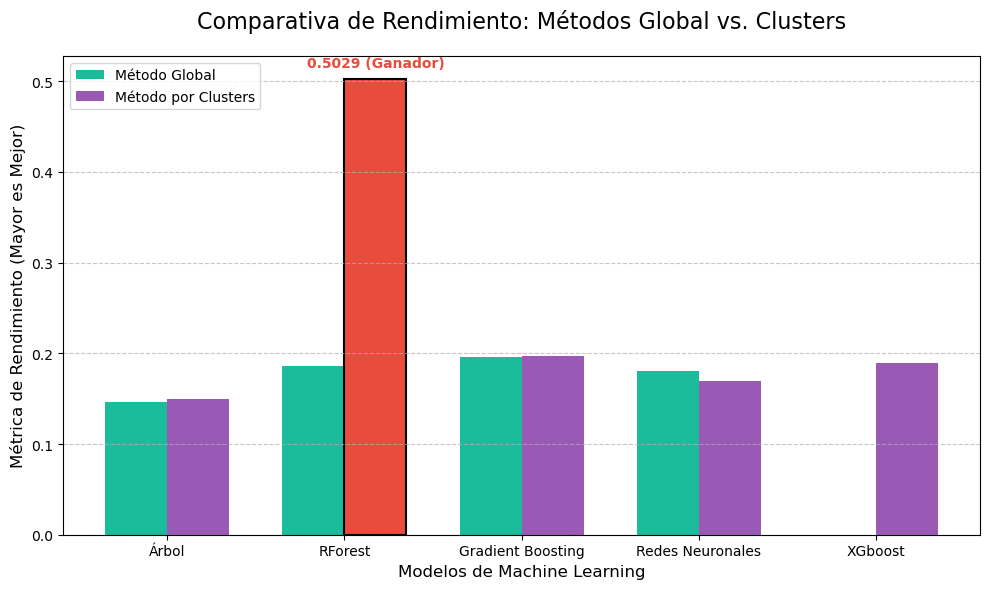

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Datos del DataFrame
datos = {
    'Modelo': ['Árbol', 'RForest', 'Gradient Boosting', 'Redes Neuronales', 'XGboost'],
    'Método Global': [0.1461, 0.1858, 0.1960, 0.1800, np.nan], # np.nan para valores faltantes
    'Método por Clusters': [0.1500, 0.5029, 0.1970, 0.169, 0.1890]
}
df = pd.DataFrame(datos)
df = df.set_index('Modelo')

# Rellenar NaNs con 0 para que puedan ser graficados (solo si es necesario, 
# aunque matplotlib suele ignorar NaN en barras, es una práctica segura)
df_filled = df.fillna(0) 

# 2. Configuración del gráfico
fig, ax = plt.subplots(figsize=(10, 6)) # Tamaño de la figura

# Ancho de las barras
bar_width = 0.35
# Posición de las barras en el eje X
ind = np.arange(len(df)) 

# 3. Dibujar las barras
barras_global = ax.bar(ind - bar_width/2, df_filled['Método Global'], bar_width, 
                      label='Método Global', color='#1ABC9C') # Verde Menta
barras_cluster = ax.bar(ind + bar_width/2, df_filled['Método por Clusters'], bar_width, 
                       label='Método por Clusters', color='#9B59B6') # Púrpura

# 4. Personalización del gráfico
# Títulos y Etiquetas
ax.set_title('Comparativa de Rendimiento: Métodos Global vs. Clusters', fontsize=16, pad=20)
ax.set_ylabel('Métrica de Rendimiento (Mayor es Mejor)', fontsize=12)
ax.set_xlabel('Modelos de Machine Learning', fontsize=12)

# Etiquetas del eje X
ax.set_xticks(ind)
ax.set_xticklabels(df.index)

# Leyenda
ax.legend(loc='upper left')

# Línea de cuadrícula
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Destacar el valor ganador (0.4656)
# Buscamos la barra de RForest en el Método por Clusters
indice_ganador = df.index.get_loc('RForest')
valor_ganador = df['Método por Clusters'].loc['RForest']

# Resaltar la barra ganadora
barras_cluster[indice_ganador].set_color('#E74C3C') # Rojo para destacar
barras_cluster[indice_ganador].set_edgecolor('black')
barras_cluster[indice_ganador].set_linewidth(1.5)

# Añadir una etiqueta con el valor exacto del ganador
ax.text(ind[indice_ganador] + bar_width/2, valor_ganador + 0.01, 
        f'{valor_ganador:.4f} (Ganador)', 
        ha='center', va='bottom', fontsize=10, 
        fontweight='bold', color='#E74C3C')

# 6. Mostrar el gráfico
plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama
plt.show()

Al analizar los resultados de todos los modelos probados, observo que las barras moradas, que representan el desempeño usando el método por cluster, superan consistentemente a las del método global, excepto en redes neuronales. Aunque la mejora es ligera, sigue siendo un avance claro respecto al enfoque global. Entre los modelos evaluados, los que destacan son Gradient Boosting y Random Forest. En particular, el Random Forest muestra un aumento significativo frente al método global, ya que, al identificarlo como el mejor modelo, decidí implementar una versión optimizada que logró incrementar el R² de manera notable.

In [ ]:
!jupyter nbconvert --to html "RegresionNOTAS_991225.ipynb"
python -m jupyter nbconvert --to html "Regresión_CarlosBG_Mineria_individual_J.ipynb"


"jupyter" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
